<a href="https://colab.research.google.com/github/leandromvs/MVP-Machine-Learning-e-Analytics-PUC-RIO/blob/main/MVP_Machine_Learning_e_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Leandro Maldonado

**Matrícula:** 4052025002138

**Datasets:** O presente estudo utiliza dados públicos oficiais do Brasil, combinando informações de consumo do varejo com variáveis macroeconômicas e indicadores estruturais.

1. [Varejo PMC – Pesquisa Mensal do Comércio – IBGE](https://sidra.ibge.gov.br/)
2. [Taxa Selic e Câmbio – Banco Central do Brasil](https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados)
3. [Inflação (IPCA) – Banco Central do Brasil](https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados)
4. [Taxa de desemprego – IBGE (PNAD Contínua)](https://sidra.ibge.gov.br/home/pnadcm)
5. [Índice de Gini – IBGE (PNAD Contínua)](https://sidra.ibge.gov.br/)

## Descrição do Problema

O objetivo é prever a variação das vendas do varejo no Brasil (dados históricos da série PMC) a partir de variáveis macroeconômicas, analisando diferenças por setor em conjunto com recortes regionais (ex.: bens essenciais vs. discricionários). Serão utilizadas variáveis como taxa de juros (Selic), inflação (IPCA), câmbio (dólar) e taxa de desocupação (desemprego), com dados mensais por estado e setor para capturar padrões temporais.

Variáveis relevantes como renda das famílias e índice de confiança do consumidor ainda não foram incluídas devido à complexidade de integração dos dados, mas serão incorporadas no próximo MVP. Ressalto que, atuando como Product Manager de dados, este foi um grande desafio, mas também muito gratificante, ao retomar a prática de codificação após tantos anos afastado.


## Hipóteses do Problema

As hipóteses que escolhi são as seguintes:

1. **É possível prever a variação das vendas do varejo a partir de variáveis como Selic, IPCA, Desemprego e câmbio?**

2. **Setores de consumo essencial e discricionário respondem de forma diferente às variáveis macroeconômicas**

3. **Oscilações da Selic afetam setores discricionários de forma diferente entre regiões com distintos níveis de desigualdade (Gini)?**

## Tipo de Problema

Este é um problema de regressão supervisionada com análise explicativa. Dado um conjunto de variáveis macroeconômicas (Selic, IPCA, desemprego e câmbio), o objetivo é prever a variação das vendas do varejo (variável contínua). Além da previsão, busca-se entender como essas variáveis impactam diferentes setores especialmente consumo essencial vs. discricionário e como esse comportamento varia entre regiões com diferentes níveis de desigualdade.

## Seleção de Dados

A base principal (IBGE) fornece informações estruturadas sobre o varejo. As demais bases são incorporadas para enriquecer o modelo (BCB e IBGE/PNAD).

As principais etapas de preparação incluíram:

1. padronização da frequéncia temporal (mensal)
2. agregação de dados diários (câmbio)
3. replicação do Índice de Gini (anual) para frequéncia mensal
4. integração das bases por data e estado

## Atributos do Dataset

O dataset final foi estruturado em formato tabular único (flat), integrando dados de diferentes fontes. A seguir segue descrição das variáveis utilizadas:

1. **data** – Mês e ano de referência (AAAA-MM).
2. **estado** – Unidade federativa da observação (Sigla/Nome).
3. **setor** – Segmento do varejo (Categórica).
4. **vendas** – Índice de volume de vendas do varejo (Número de Índice - Base: 2014=100).
5. **variacao_vendas** – Variação percentual das vendas (Variação % Mês/Mês).
6. **selic** – Taxa básica de juros mensal (% ao mês).
7. **dolar** – Cotação média mensal do dólar (R$/USD).
8. **ipca** – Índice oficial de inflação (Variação % mensal).
9. **Desemprego** – Precentual de desocupação (Variação % mensal)
9. **gini** – Índice de desigualdade por estado (Coeficiente de 0 a 1).
10. **ano** – Ano da observação (Ano Civil).
11. **mes** – Mês da observação (1 a 12).

## Considerações

Embora os efeitos macroeconômicos sejam bem estabelecidos, a análise por setores revela nuances do consumo e permite identificar padrões específicos.

Este trabalho também servirá de base para o próximo e último MVP (Machine Learning e Analytics), com análises mais granulares em categorias relevantes (ex.: Volume de vendas de SUVs vs. variáveis econômicas e socioeconômicas), ampliando o potencial de aplicação em análises mais específicas.

Assim, este MVP será a transição de uma visão macroeconômica para uma análise microeconômica aplicada (setorial), ainda que combinada com dados macroeconômicos, orientando novas hipóteses e escolha de um setor específico para aprofundamento no próximo MVP.


# Importação das Bibliotecas, definindo formatações, unificação e carga de Dados

Esta seção consolida as bibliotecas necessárias para análise, visualização e pré-processamento dos dados, além do carregamento inicial dos datasets via APIs do IBGE e do Banco Central. Também inclui a etapa de unificação das bases em uma única tabela analítica, processo mais complexo e essencial para viabilizar as análises.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import requests

from dateutil.relativedelta import relativedelta

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

print("bibliotecas importadas com sucesso")

bibliotecas importadas com sucesso


## Bases do Banco central do Brasil (BCB)

In [ ]:
# definindo período de análise
DATA_INICIO = "2015-01-01"
DATA_FIM = "2025-12-31"

# definindo códigos das séries do banco central
CODIGO_SELIC = "11"
CODIGO_DOLAR = "1"
CODIGO_IPCA = "433"
CODIGO_DESEMPREGO = "24369"  # Taxa média de desocupação - PNAD Contínua / SGS-BCB

print("parâmetros definidos com sucesso")
print(f"período do estudo: {DATA_INICIO} até {DATA_FIM}")


parâmetros definidos com sucesso
período do estudo: 2015-01-01 até 2025-12-31


In [ ]:
class BancoCentralClient:
    def __init__(self, data_inicio: str, data_fim: str):
        self.data_inicio = pd.to_datetime(data_inicio)
        self.data_fim = pd.to_datetime(data_fim)
        self.url_base = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados"
        self.limite_anos = 10

    def _formatar_data(self, data: pd.Timestamp) -> str:
        return data.strftime("%d/%m/%Y")

    def _montar_url(self, codigo_serie: str) -> str:
        return self.url_base.format(codigo=codigo_serie)

    def _gerar_janelas(self):
        data_atual = self.data_inicio

        while data_atual <= self.data_fim:
            data_final_janela = min(
                data_atual + relativedelta(years=self.limite_anos) - relativedelta(days=1),
                self.data_fim
            )

            yield data_atual, data_final_janela
            data_atual = data_final_janela + relativedelta(days=1)

    def _fazer_requisicao(self, codigo_serie: str, data_inicio: pd.Timestamp, data_fim: pd.Timestamp) -> list:
        url = self._montar_url(codigo_serie)

        params = {
            "formato": "json",
            "dataInicial": self._formatar_data(data_inicio),
            "dataFinal": self._formatar_data(data_fim)
        }

        headers = {
            "Accept": "application/json"
        }

        response = requests.get(url, params=params, headers=headers, timeout=30)
        response.raise_for_status()

        return response.json()

    def _converter_para_dataframe(self, dados: list) -> pd.DataFrame:
        df = pd.DataFrame(dados)

        if df.empty:
            return df

        df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y")
        df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

        return df

    def carregar_serie(self, codigo_serie: str, nome_coluna: str) -> pd.DataFrame:
        lista_dataframes = []

        for data_inicio_janela, data_fim_janela in self._gerar_janelas():
            dados = self._fazer_requisicao(
                codigo_serie=codigo_serie,
                data_inicio=data_inicio_janela,
                data_fim=data_fim_janela
            )

            df_parcial = self._converter_para_dataframe(dados)

            if not df_parcial.empty:
                lista_dataframes.append(df_parcial)

        if not lista_dataframes:
            raise ValueError(f"nenhum dado retornado para a série {codigo_serie}")

        df = pd.concat(lista_dataframes, ignore_index=True)

        df = df.drop_duplicates(subset=["data"]).sort_values("data").reset_index(drop=True)

        df = df.rename(columns={"valor": nome_coluna})

        return df

print("classe do banco central criada com sucesso")

classe do banco central criada com sucesso


In [ ]:
def adicionar_coluna_ano_mes(df: pd.DataFrame, coluna_data: str = "data") -> pd.DataFrame:
    df_resultado = df.copy()
    df_resultado["ano_mes"] = df_resultado[coluna_data].dt.to_period("M").astype(str)
    return df_resultado

def agregar_media_mensal(df: pd.DataFrame, coluna_valor: str) -> pd.DataFrame:
    df_resultado = (
        df.groupby("ano_mes", as_index=False)[coluna_valor]
        .mean()
        .copy()
    )
    return df_resultado

def selecionar_colunas_mensais(df: pd.DataFrame, nome_coluna: str) -> pd.DataFrame:
    df_resultado = df[["ano_mes", nome_coluna]].copy()
    return df_resultado

def converter_ano_mes_para_data(df: pd.DataFrame, coluna_ano_mes: str = "ano_mes") -> pd.DataFrame:
    df_resultado = df.copy()
    df_resultado["data"] = pd.to_datetime(df_resultado[coluna_ano_mes] + "-01")
    return df_resultado

def ordenar_por_data(df: pd.DataFrame, coluna_data: str = "data") -> pd.DataFrame:
    df_resultado = df.sort_values(coluna_data).reset_index(drop=True).copy()
    return df_resultado

In [ ]:
# instanciando cliente para acessar dados do banco central
bcb_client = BancoCentralClient(
    data_inicio=DATA_INICIO,
    data_fim=DATA_FIM
)

print("cliente do banco central instanciado com sucesso")

cliente do banco central instanciado com sucesso


In [ ]:
# carregando série da selic
df_selic = bcb_client.carregar_serie(
    codigo_serie=CODIGO_SELIC,
    nome_coluna="selic"
)

# visualizando primeiras linhas da selic
display(df_selic.head())

# visualizando últimas linhas da selic
display(df_selic.tail())

# verificando estrutura da selic
df_selic.info()

,data,selic
0,2015-01-02,0.0437
1,2015-01-05,0.0437
2,2015-01-06,0.0437
3,2015-01-07,0.0437
4,2015-01-08,0.0437


,data,selic
2755,2025-12-24,0.0551
2756,2025-12-26,0.0551
2757,2025-12-29,0.0551
2758,2025-12-30,0.0551
2759,2025-12-31,0.0551


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760 entries, 0 to 2759
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   data    2760 non-null   datetime64[ns]
 1   selic   2760 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 43.3 KB


In [ ]:
# carregando série do dólar
df_dolar = bcb_client.carregar_serie(
    codigo_serie=CODIGO_DOLAR,
    nome_coluna="dolar"
)

# visualizando primeiras linhas do dólar
display(df_dolar.head())

# visualizando últimas linhas do dólar
display(df_dolar.tail())

# verificando estrutura do dólar
df_dolar.info()

,data,dolar
0,2015-01-02,2.6929
1,2015-01-05,2.7107
2,2015-01-06,2.7023
3,2015-01-07,2.6807
4,2015-01-08,2.6919


,data,dolar
2755,2025-12-24,5.5350
2756,2025-12-26,5.5413
2757,2025-12-29,5.5739
2758,2025-12-30,5.5024
2759,2025-12-31,5.5024


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760 entries, 0 to 2759
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   data    2760 non-null   datetime64[ns]
 1   dolar   2760 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 43.3 KB


In [ ]:
# carregando série do ipca
df_ipca = bcb_client.carregar_serie(
    codigo_serie=CODIGO_IPCA,
    nome_coluna="ipca"
)

# visualizando primeiras linhas do ipca
display(df_ipca.head())

# visualizando últimas linhas do ipca
display(df_ipca.tail())

# verificando estrutura do ipca
df_ipca.info()

,data,ipca
0,2015-01-01,1.2400
1,2015-02-01,1.2200
2,2015-03-01,1.3200
3,2015-04-01,0.7100
4,2015-05-01,0.7400


,data,ipca
127,2025-08-01,-0.1100
128,2025-09-01,0.4800
129,2025-10-01,0.0900
130,2025-11-01,0.1800
131,2025-12-01,0.3300


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   data    132 non-null    datetime64[ns]
 1   ipca    132 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 KB


In [ ]:
# carregando série de desemprego

df_desemprego = bcb_client.carregar_serie(
    codigo_serie=CODIGO_DESEMPREGO,
    nome_coluna="desemprego"
)

display(df_desemprego.head())
df_desemprego.info()

,data,desemprego
0,2015-01-01,6.9000
1,2015-02-01,7.5000
2,2015-03-01,8.0000
3,2015-04-01,8.1000
4,2015-05-01,8.2000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data        132 non-null    datetime64[ns]
 1   desemprego  132 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 KB


In [ ]:
# adicionando coluna de ano_mes na selic
df_selic = adicionar_coluna_ano_mes(df_selic)
df_dolar = adicionar_coluna_ano_mes(df_dolar)
df_ipca = adicionar_coluna_ano_mes(df_ipca)
df_desemprego = adicionar_coluna_ano_mes(df_desemprego)

print("coluna ano_mes adicionada em todas as séries")

coluna ano_mes adicionada em todas as séries


In [ ]:
# agregando séries por média mensal
df_dolar_mensal = agregar_media_mensal(
    df=df_dolar,
    coluna_valor="dolar"
)

df_ipca_mensal = agregar_media_mensal(
    df=df_ipca,
    coluna_valor="ipca"
)

df_desemprego_mensal = agregar_media_mensal(
    df=df_desemprego,
    coluna_valor="desemprego"
)

print("agregações mensais concluídas")

agregações mensais concluídas


In [ ]:
# selecionando colunas finais das séries mensais
df_selic_mensal = selecionar_colunas_mensais(
    df=df_selic,
    nome_coluna="selic"
)

df_dolar_mensal = selecionar_colunas_mensais(
    df=df_dolar_mensal,
    nome_coluna="dolar"
)

df_ipca_mensal = selecionar_colunas_mensais(
    df=df_ipca_mensal,
    nome_coluna="ipca"
)

df_desemprego_mensal = selecionar_colunas_mensais(
    df=df_desemprego_mensal,
    nome_coluna="desemprego"
)

print("seleção de colunas mensais concluída")

seleção de colunas mensais concluída


In [ ]:
# criando função para integrar séries macroeconômicas do BCB
def integrar_series_macro(
    df_selic_mensal: pd.DataFrame,
    df_dolar_mensal: pd.DataFrame,
    df_ipca_mensal: pd.DataFrame,
    df_desemprego_mensal: pd.DataFrame
) -> pd.DataFrame:

    df_macro = (
        df_selic_mensal
        .merge(df_dolar_mensal, on="ano_mes", how="outer")
        .merge(df_ipca_mensal, on="ano_mes", how="outer")
        .merge(df_desemprego_mensal, on="ano_mes", how="outer")
    )

    df_macro = converter_ano_mes_para_data(df_macro)
    df_macro = ordenar_por_data(df_macro, coluna_data="data")

    return df_macro


In [ ]:
# integrando séries macroeconômicas em um dataframe único
df_macro = integrar_series_macro(
    df_selic_mensal=df_selic_mensal,
    df_dolar_mensal=df_dolar_mensal,
    df_ipca_mensal=df_ipca_mensal,
    df_desemprego_mensal=df_desemprego_mensal
)

display(df_macro.head())
df_macro.info()


,ano_mes,selic,dolar,ipca,desemprego,data
0,2015-01,0.0437,2.6342,1.2400,6.9000,2015-01-01
1,2015-01,0.0455,2.6342,1.2400,6.9000,2015-01-01
2,2015-01,0.0455,2.6342,1.2400,6.9000,2015-01-01
3,2015-01,0.0455,2.6342,1.2400,6.9000,2015-01-01
4,2015-01,0.0455,2.6342,1.2400,6.9000,2015-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760 entries, 0 to 2759
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ano_mes     2760 non-null   object        
 1   selic       2760 non-null   float64       
 2   dolar       2760 non-null   float64       
 3   ipca        2760 non-null   float64       
 4   desemprego  2760 non-null   float64       
 5   data        2760 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 129.5+ KB


In [ ]:
# verificando quantidade de valores ausentes na base macroeconômica
df_macro[["selic", "dolar", "ipca", "desemprego"]].isnull().sum()


,0
selic,0
dolar,0
ipca,0
desemprego,0


In [ ]:
# visualizando estatísticas descritivas da base macroeconômica
df_macro[["selic", "dolar", "ipca", "desemprego"]].describe()


,selic,dolar,ipca,desemprego
count,"2,760.0000","2,760.0000","2,760.0000","2,760.0000"
mean,0.0369,4.4845,0.4537,10.3995
std,0.0152,0.9450,0.4004,2.7360
min,0.0075,2.6342,-0.6800,5.1000
25%,0.0246,3.6361,0.2200,7.9000
50%,0.0420,4.8972,0.4000,11.3000
75%,0.0508,5.3294,0.7100,12.5000
max,0.0551,6.0970,1.6200,14.9000


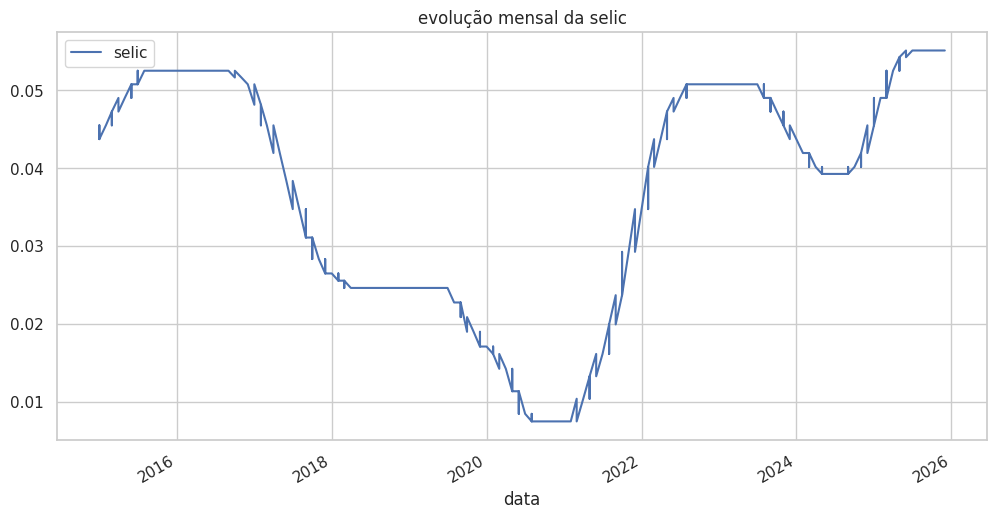

In [ ]:
# visualizando evolução da selic para entendimento da validade do dado frente
# ao que consta no site do BC é diferente, pois a escala é anual no site do BC, mas e esta escala é mensal.
# O valor bate quando comparado o acumulado mensal e a curva dos 10 anos é identica
df_macro.plot(x="data", y="selic", title="evolução mensal da selic")
plt.show()



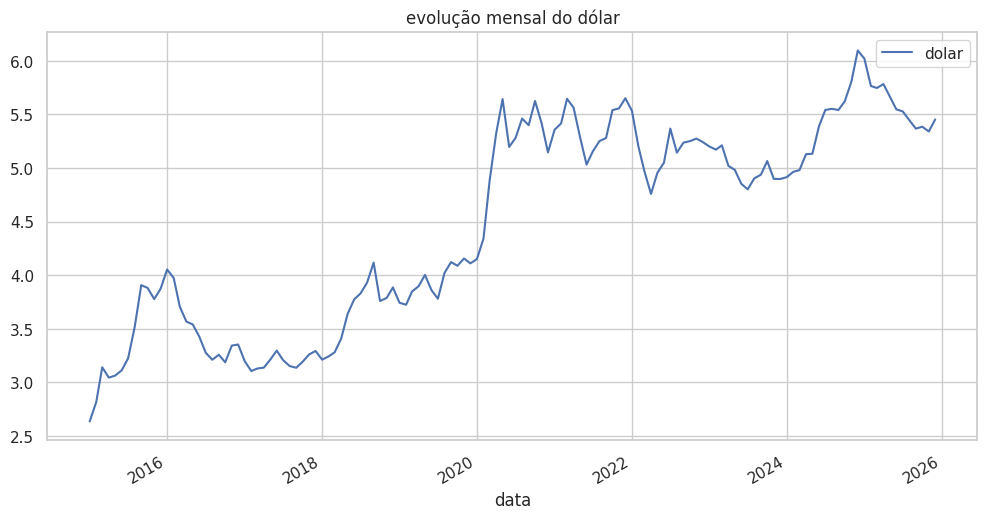

In [ ]:
# visualizando evolução do dólar
df_macro.plot(x="data", y="dolar", title="evolução mensal do dólar")
plt.show()



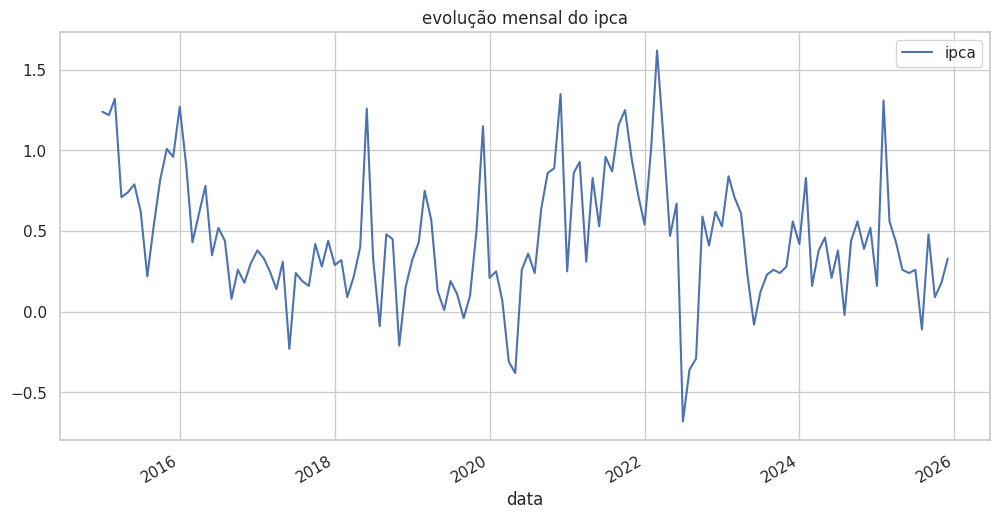

In [ ]:
# visualizando evolução do ipca
df_macro.plot(x="data", y="ipca", title="evolução mensal do ipca")
plt.show()

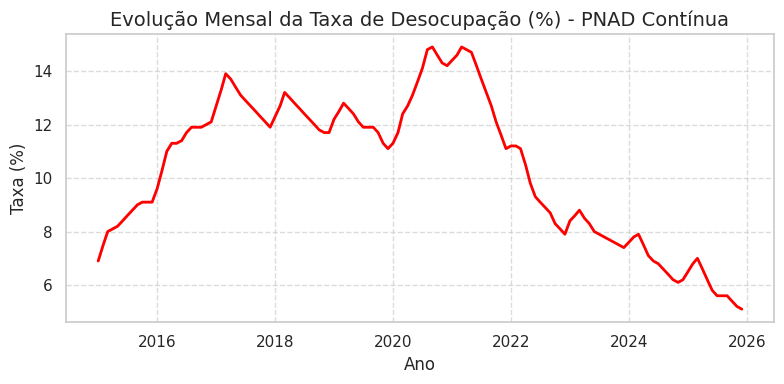

In [ ]:
# visualizando evolucao da taxa de desocupacao (desemprego)
plt.figure(figsize=(8, 4))
sns.lineplot(data=df_macro, x='data', y='desemprego', color='red', linewidth=2)

plt.title('Evolução Mensal da Taxa de Desocupação (%) - PNAD Contínua', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Taxa (%)')
plt.grid(True, linestyle='--', alpha=0.7)

# Garantindo que o eixo X mostre os anos claramente
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [ ]:
# salvando base macroeconômica tratada em csv
df_macro.to_csv("df_macro_mensal.csv", index=False)

print("base macroeconômica salva com sucesso")

base macroeconômica salva com sucesso


## Base Sindra (IBGE): Pesquisa Mensal de Comércio (PMC) e Gini

In [ ]:
# Definindo parâmetros necessários para acessar dados do sidra (PMC e PNAD Contínua)
URL_SIDRA_BASE = "https://apisidra.ibge.gov.br"
TABELA_PMC = "8882"
TABELA_GINI = "7435"
TABELA_DESEMPREGO_PNAD = "6408" # Adicionado para PNAD Contínua

USAR_RENDA = False # Flag para ativar/desativar a consulta da tabela de renda
TABELA_RENDA = None # Código da tabela de renda, será None se USAR_RENDA for False

NIVEL_GEOGRAFICO_ESTADO = "n3"
PERIODO_PMC = "201201-202512"
PERIODO_ANUAL = "2012-2024"

print("Parâmetros configurados com sucesso.")
print(f"Tabela PMC: {TABELA_PMC} | Tabela Gini: {TABELA_GINI} | Tabela Desemprego PNAD: {TABELA_DESEMPREGO_PNAD}")
print(f"Nível Geográfico: {NIVEL_GEOGRAFICO_ESTADO}")

Parâmetros configurados com sucesso.
Tabela PMC: 8882 | Tabela Gini: 7435 | Tabela Desemprego PNAD: 6408
Nível Geográfico: n3


In [ ]:
import requests

class SidraClient:

    def __init__(self, url_base: str = URL_SIDRA_BASE):
        self.url_base = url_base

    def _fazer_requisicao(self, endpoint: str):
        url = f"{self.url_base}{endpoint}"

        headers = {
            "Accept": "application/json"
        }

        try:
            response = requests.get(url, headers=headers, timeout=60)
            response.raise_for_status()

            return response.json()

        except requests.exceptions.HTTPError as http_err:
            if response.status_code == 400:
                raise ValueError(f"Erro 400: Requisição inválida ao SIDRA. Verifique o endpoint: {endpoint}. Detalhes: {http_err}")
            else:
                raise RuntimeError(f"Erro HTTP ao acessar SIDRA: {http_err}") from http_err
        except requests.exceptions.ConnectionError as conn_err:
            raise RuntimeError(f"Erro de Conexão ao acessar SIDRA: {conn_err}") from conn_err
        except requests.exceptions.Timeout as timeout_err:
            raise RuntimeError(f"Tempo limite excedido ao acessar SIDRA: {timeout_err}") from timeout_err
        except requests.exceptions.RequestException as req_err:
            raise RuntimeError(f"Erro inesperado ao acessar SIDRA: {req_err}") from req_err

    def obter_descritores_tabela(self, tabela: str):
        endpoint = f"/DescritoresTabela/t/{tabela}"
        return self._fazer_requisicao(endpoint)

    def carregar_valores(self, endpoint_values: str) -> pd.DataFrame:
        dados = self._fazer_requisicao(endpoint_values)
        return pd.DataFrame(dados)

print("classe do sidra criada com sucesso")

classe do sidra criada com sucesso


In [ ]:
# instanciando cliente para realizar consultas na api do sidra

sidra_client = SidraClient()

print("cliente do sidra instanciado com sucesso")

cliente do sidra instanciado com sucesso


In [ ]:
# consultando descritores da tabela da pmc para identificar variáveis e classificações

descritores_pmc = sidra_client.obter_descritores_tabela(TABELA_PMC)

# verificando tipo do retorno da api
print(type(descritores_pmc))

# visualizando estrutura geral do retorno
if isinstance(descritores_pmc, dict):
    print("chaves disponíveis no retorno:")
    print(list(descritores_pmc.keys()))
elif isinstance(descritores_pmc, list):
    print("quantidade de itens retornados:")
    print(len(descritores_pmc))
    print("exemplo do primeiro item:")
    print(descritores_pmc[0])
else:
    print("estrutura inesperada:")
    print(descritores_pmc)

<class 'dict'>
chaves disponíveis no retorno:
['Id', 'Nome', 'Pesquisa', 'PlanoDivulgacao', 'Assunto', 'TipoPeriodo', 'NomeTituloTerritorial', 'NomeTituloTemporal', 'QuantidadeClassificacoes', 'QuantidadeNiveisTerritoriais', 'QuantidadeDimensoes', 'PeriodoDisponibilidade', 'SiglasNiveisTerritoriais', 'Variaveis', 'Classificacoes', 'Periodos', 'ConjuntosPeriodos', 'NiveisTerritoriais', 'VisoesTerritoriais', 'Fonte', 'DataAtualizacao']


In [ ]:
# criando função para organizar descritores do sidra em dataframes separados

def organizar_descritores_sidra(descritores: object) -> dict:

    # criando dicionário para armazenar as seções convertidas
    dfs_descritores = {}

    # tratando caso em que o retorno seja um dicionário
    if isinstance(descritores, dict):
        for chave, valor in descritores.items():

            # convertendo listas em dataframe
            if isinstance(valor, list):
                try:
                    dfs_descritores[chave] = pd.DataFrame(valor)
                except Exception:
                    dfs_descritores[chave] = pd.json_normalize(valor)

            # convertendo dicionários em dataframe
            elif isinstance(valor, dict):
                dfs_descritores[chave] = pd.DataFrame([valor])

            # convertendo valores simples em dataframe
            else:
                dfs_descritores[chave] = pd.DataFrame([{chave: valor}])

    # tratando caso em que o retorno seja uma lista
    elif isinstance(descritores, list):
        try:
            dfs_descritores["descritores"] = pd.DataFrame(descritores)
        except Exception:
            dfs_descritores["descritores"] = pd.json_normalize(descritores)

    # tratando qualquer outro formato de retorno
    else:
        dfs_descritores["descritores"] = pd.DataFrame([{"valor": descritores}])

    return dfs_descritores

print("função para organizar descritores criada com sucesso")

função para organizar descritores criada com sucesso


In [ ]:
# organizando descritores da pmc em múltiplos dataframes para facilitar a inspeção

dfs_descritores_pmc = organizar_descritores_sidra(descritores_pmc)

# visualizando nomes das seções encontradas
print("seções disponíveis nos descritores da pmc:")
print(list(dfs_descritores_pmc.keys()))

seções disponíveis nos descritores da pmc:
['Id', 'Nome', 'Pesquisa', 'PlanoDivulgacao', 'Assunto', 'TipoPeriodo', 'NomeTituloTerritorial', 'NomeTituloTemporal', 'QuantidadeClassificacoes', 'QuantidadeNiveisTerritoriais', 'QuantidadeDimensoes', 'PeriodoDisponibilidade', 'SiglasNiveisTerritoriais', 'Variaveis', 'Classificacoes', 'Periodos', 'ConjuntosPeriodos', 'NiveisTerritoriais', 'VisoesTerritoriais', 'Fonte', 'DataAtualizacao']


In [ ]:
# consultando descritores da tabela de renda apenas se a opção estiver ativa
if USAR_RENDA and TABELA_RENDA:
    descritores_renda = sidra_client.obter_descritores_tabela(TABELA_RENDA)

    print(type(descritores_renda))

    if isinstance(descritores_renda, dict):
        print("chaves disponíveis no retorno:")
        print(list(descritores_renda.keys()))
    elif isinstance(descritores_renda, list):
        print("quantidade de itens retornados:")
        print(len(descritores_renda))
        print("exemplo do primeiro item:")
        print(descritores_renda[0])
    else:
        print("estrutura inesperada:")
        print(descritores_renda)
else:
    descritores_renda = None
    print("consulta de renda desativada nesta versão do notebook")


consulta de renda desativada nesta versão do notebook


In [ ]:
# organizando descritores da renda em múltiplos dataframes para facilitar a inspeção
if descritores_renda is not None:
    dfs_descritores_renda = organizar_descritores_sidra(descritores_renda)
else:
    dfs_descritores_renda = {}
    print("sem descritores de renda para organizar")


sem descritores de renda para organizar


In [ ]:
# inspecionando cada seção dos descritores da renda para identificar variável, classificação e categoria total
if dfs_descritores_renda:
    for nome_secao, df_secao in dfs_descritores_renda.items():
        print(f"\nseção: {nome_secao}")
        display(df_secao.head())
else:
    print("inspeção de renda ignorada")


inspeção de renda ignorada


In [ ]:
# consultando descritores da tabela de gini para identificar a variável correta

descritores_gini = sidra_client.obter_descritores_tabela(TABELA_GINI)

# verificando tipo do retorno da api
print(type(descritores_gini))

# visualizando estrutura geral do retorno
if isinstance(descritores_gini, dict):
    print("chaves disponíveis no retorno:")
    print(list(descritores_gini.keys()))
elif isinstance(descritores_gini, list):
    print("quantidade de itens retornados:")
    print(len(descritores_gini))
    print("exemplo do primeiro item:")
    print(descritores_gini[0])
else:
    print("estrutura inesperada:")
    print(descritores_gini)

<class 'dict'>
chaves disponíveis no retorno:
['Id', 'Nome', 'Pesquisa', 'PlanoDivulgacao', 'Assunto', 'TipoPeriodo', 'NomeTituloTerritorial', 'NomeTituloTemporal', 'QuantidadeClassificacoes', 'QuantidadeNiveisTerritoriais', 'QuantidadeDimensoes', 'PeriodoDisponibilidade', 'SiglasNiveisTerritoriais', 'Variaveis', 'Classificacoes', 'Periodos', 'ConjuntosPeriodos', 'NiveisTerritoriais', 'VisoesTerritoriais', 'Nota', 'Fonte', 'DataAtualizacao']


In [ ]:
# organizando descritores do gini em múltiplos dataframes para facilitar a inspeção

dfs_descritores_gini = organizar_descritores_sidra(descritores_gini)

# mantendo apenas seções que realmente são dataframes
dfs_descritores_gini = {
    nome_secao: df_secao
    for nome_secao, df_secao in dfs_descritores_gini.items()
    if isinstance(df_secao, pd.DataFrame)
}

# visualizando nomes das seções encontradas
print("seções disponíveis nos descritores do gini:")
print(list(dfs_descritores_gini.keys()))

seções disponíveis nos descritores do gini:
['Id', 'Nome', 'Pesquisa', 'PlanoDivulgacao', 'Assunto', 'TipoPeriodo', 'NomeTituloTerritorial', 'NomeTituloTemporal', 'QuantidadeClassificacoes', 'QuantidadeNiveisTerritoriais', 'QuantidadeDimensoes', 'PeriodoDisponibilidade', 'SiglasNiveisTerritoriais', 'Variaveis', 'Classificacoes', 'Periodos', 'ConjuntosPeriodos', 'NiveisTerritoriais', 'VisoesTerritoriais', 'Nota', 'Fonte', 'DataAtualizacao']


In [ ]:
# inspecionando cada seção válida dos descritores do gini para identificar a variável correta

for nome_secao, df_secao in dfs_descritores_gini.items():
    print(f"\nseção: {nome_secao}")
    display(df_secao.head())
    print(df_secao.shape)


seção: Id


,Id
0,7435


(1, 1)

seção: Nome


,Nome
0,Índice de Gini do rendimento domiciliar per ca...


(1, 1)

seção: Pesquisa


...

(1, 1)

seção: Fonte


,Fonte
0,IBGE. Pesquisa Nacional por Amostra de Domic&i...


(1, 1)

seção: DataAtualizacao


,DataAtualizacao
0,2026-02-02 13:26:54


(1, 1)


In [ ]:
# definindo parâmetros específicos das consultas após inspecionar os descritores

# definindo código da variável da pmc
VARIAVEL_PMC = "7169"

# definindo classificações necessárias da pmc
CLASSIFICACOES_PMC = {
    "11046": "56734",
    "85": "all"
}

# parâmetros de renda ficam opcionais nesta versão
VARIAVEL_RENDA = None
CLASSIFICACOES_RENDA = None

# definindo código da variável do gini
VARIAVEL_GINI = "10681"

print("parâmetros específicos definidos com sucesso")


parâmetros específicos definidos com sucesso


In [ ]:
# criando função para montar endpoint do sidra
def montar_endpoint_sidra(
    tabela: str,
    nivel_geografico: str,
    variavel: str,
    periodo: str,
    classificacoes: dict | None = None
) -> str:

    endpoint = f"/values/t/{tabela}/{nivel_geografico}/all/v/{variavel}/p/{periodo}"

    if classificacoes:
        for codigo_classificacao, codigo_categoria in classificacoes.items():
            endpoint += f"/c{codigo_classificacao}/{codigo_categoria}"

    endpoint += "/h/n"

    return endpoint

In [ ]:
# montando endpoint da pmc com múltiplas classificações

endpoint_pmc = montar_endpoint_sidra(
    tabela=TABELA_PMC,
    nivel_geografico=NIVEL_GEOGRAFICO_ESTADO,
    variavel=VARIAVEL_PMC,
    periodo=PERIODO_PMC,
    classificacoes=CLASSIFICACOES_PMC
)

print(endpoint_pmc)

/values/t/8882/n3/all/v/7169/p/201201-202512/c11046/56734/c85/all/h/n


In [ ]:
# montando endpoint da renda com base nos parâmetros definidos
if USAR_RENDA and TABELA_RENDA and VARIAVEL_RENDA:
    endpoint_renda = montar_endpoint_sidra(
        tabela=TABELA_RENDA,
        nivel_geografico=NIVEL_GEOGRAFICO_ESTADO,
        variavel=VARIAVEL_RENDA,
        periodo=PERIODO_ANUAL,
        classificacoes=CLASSIFICACOES_RENDA
    )

    print(endpoint_renda)
else:
    endpoint_renda = None
    print("endpoint de renda não gerado porque USAR_RENDA=False")


endpoint de renda não gerado porque USAR_RENDA=False


In [ ]:
# montando endpoint do gini com o código correto

endpoint_gini = montar_endpoint_sidra(
    tabela=TABELA_GINI,
    nivel_geografico=NIVEL_GEOGRAFICO_ESTADO,
    variavel=VARIAVEL_GINI,
    periodo=PERIODO_ANUAL
)

print(endpoint_gini)

/values/t/7435/n3/all/v/10681/p/2012-2024/h/n


In [ ]:
# validando endpoints antes de chamar a api

print("endpoint pmc:")
print(endpoint_pmc)

print("\nendpoint renda:")
print(endpoint_renda)

print("\nendpoint gini:")
print(endpoint_gini)

endpoint pmc:
/values/t/8882/n3/all/v/7169/p/201201-202512/c11046/56734/c85/all/h/n

endpoint renda:
None

endpoint gini:
/values/t/7435/n3/all/v/10681/p/2012-2024/h/n


In [ ]:
# carregando base bruta da pmc a partir do endpoint corrigido

try:
    df_pmc_raw = sidra_client.carregar_valores(endpoint_pmc)

    # visualizando primeiras linhas da base bruta
    display(df_pmc_raw.head())

    # verificando estrutura da base bruta
    df_pmc_raw.info()

except Exception as e:
    print("erro ao carregar pmc:")
    print(e)

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N,D5C,D5N
0,3,Unidade da Federação,30,Número-índice,102.86127,23,Ceará,7169,PMC - Número-índice (2022=100),201201,janeiro 2012,56734,Índice de volume de vendas no comércio varejista,90671,Combustíveis e lubrificantes
1,3,Unidade da Federação,30,Número-índice,103.66854,23,Ceará,7169,PMC - Número-índice (2022=100),201201,janeiro 2012,56734,Índice de volume de vendas no comércio varejista,90672,"Hipermercados, supermercados, produtos aliment..."
2,3,Unidade da Federação,30,Número-índice,110.86054,23,Ceará,7169,PMC - Número-índice (2022=100),201201,janeiro 2012,56734,Índice de volume de vendas no comércio varejista,103154,Hipermercados e supermercados
3,3,Unidade da Federação,30,Número-índice,81.18028,23,Ceará,7169,PMC - Número-índice (2022=100),201201,janeiro 2012,56734,Índice de volume de vendas no comércio varejista,90673,"Tecidos, vestuário e calçados"
4,3,Unidade da Federação,30,Número-índice,129.90724,23,Ceará,7169,PMC - Número-índice (2022=100),201201,janeiro 2012,56734,Índice de volume de vendas no comércio varejista,2759,Móveis e eletrodomésticos


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22176 entries, 0 to 22175
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NC      22176 non-null  object
 1   NN      22176 non-null  object
 2   MC      22176 non-null  object
 3   MN      22176 non-null  object
 4   V       22176 non-null  object
 5   D1C     22176 non-null  object
 6   D1N     22176 non-null  object
 7   D2C     22176 non-null  object
 8   D2N     22176 non-null  object
 9   D3C     22176 non-null  object
 10  D3N     22176 non-null  object
 11  D4C     22176 non-null  object
 12  D4N     22176 non-null  object
 13  D5C     22176 non-null  object
 14  D5N     22176 non-null  object
dtypes: object(15)
memory usage: 2.5+ MB


In [ ]:
# carregando base bruta da renda a partir do endpoint montado
if endpoint_renda:
    try:
        df_renda_raw = sidra_client.carregar_valores(endpoint_renda)
        display(df_renda_raw.head())
        df_renda_raw.info()
    except Exception as e:
        print("erro ao carregar renda:")
        print(e)
        df_renda_raw = None
else:
    df_renda_raw = None
    print("carga de renda ignorada nesta execução")


carga de renda ignorada nesta execução


In [ ]:
# carregando base bruta do gini a partir do endpoint montado

try:
    df_gini_raw = sidra_client.carregar_valores(endpoint_gini)

    # visualizando primeiras linhas da base bruta
    display(df_gini_raw.head())

    # verificando estrutura da base bruta
    df_gini_raw.info()

except Exception as e:
    print("erro ao carregar gini:")
    print(e)

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,3,Unidade da Federação,50,Índice,0.487,11,Rondônia,10681,Índice de Gini do rendimento domiciliar per ca...,2012,2012
1,3,Unidade da Federação,50,Índice,0.475,11,Rondônia,10681,Índice de Gini do rendimento domiciliar per ca...,2013,2013
2,3,Unidade da Federação,50,Índice,0.443,11,Rondônia,10681,Índice de Gini do rendimento domiciliar per ca...,2014,2014
3,3,Unidade da Federação,50,Índice,0.462,11,Rondônia,10681,Índice de Gini do rendimento domiciliar per ca...,2015,2015
4,3,Unidade da Federação,50,Índice,0.465,11,Rondônia,10681,Índice de Gini do rendimento domiciliar per ca...,2016,2016


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NC      351 non-null    object
 1   NN      351 non-null    object
 2   MC      351 non-null    object
 3   MN      351 non-null    object
 4   V       351 non-null    object
 5   D1C     351 non-null    object
 6   D1N     351 non-null    object
 7   D2C     351 non-null    object
 8   D2N     351 non-null    object
 9   D3C     351 non-null    object
 10  D3N     351 non-null    object
dtypes: object(11)
memory usage: 30.3+ KB


## Padronização, qualidade e integração das bases

Esta seção reorganiza as bases carregadas, padroniza a estrutura das tabelas do Sidra, trata diferenças de granularidade entre fontes mensais e anuais e monta a base analítica final do projeto em formato tabular único.

In [ ]:
import pandas as pd
import numpy as np

def normalizar_texto(texto: str) -> str:
    texto = str(texto).strip().lower()
    texto = texto.replace("ã", "a")
    texto = texto.replace("á", "a")
    texto = texto.replace("à", "a")
    texto = texto.replace("â", "a")
    texto = texto.replace("é", "e")
    texto = texto.replace("ê", "e")
    texto = texto.replace("í", "i")
    texto = texto.replace("ó", "o")
    texto = texto.replace("ô", "o")
    texto = texto.replace("ú", "u")
    texto = texto.replace("ç", "c")
    texto = texto.replace("(", "")
    texto = texto.replace(")", "")
    texto = texto.replace("/", "_")
    texto = texto.replace("-", "_")
    texto = texto.replace(" ", "_")

    while "__" in texto:
        texto = texto.replace("__", "_")

    return texto.strip("_")

def padronizar_nomes_colunas(df: pd.DataFrame) -> pd.DataFrame:
    df_resultado = df.copy()
    df_resultado.columns = [normalizar_texto(col) for col in df_resultado.columns]
    return df_resultado

def converter_valor_numerico(serie: pd.Series) -> pd.Series:
    serie_resultado = serie.astype("string").str.strip()
    serie_resultado = serie_resultado.replace({"..": pd.NA, "...": pd.NA, "-": pd.NA, "nan": pd.NA, "None": pd.NA})
    serie_resultado = serie_resultado.str.replace(".", "", regex=False)
    serie_resultado = serie_resultado.str.replace(",", ".", regex=False)
    return pd.to_numeric(serie_resultado, errors="coerce")


print("funções auxiliares criadas com sucesso")

funções auxiliares criadas com sucesso


In [ ]:
ESTADOS_BRASIL = {
    "rondonia", "acre", "amazonas", "roraima", "para", "amapa", "tocantins",
    "maranhao", "piaui", "ceara", "rio_grande_do_norte", "paraiba", "pernambuco",
    "alagoas", "sergipe", "bahia", "minas_gerais", "espirito_santo", "rio_de_janeiro",
    "sao_paulo", "parana", "santa_catarina", "rio_grande_do_sul", "mato_grosso_do_sul",
    "mato_grosso", "goias", "distrito_federal"
}

def identificar_coluna_data_sidra(df: pd.DataFrame) -> tuple:
    for coluna in df.columns:
        serie = df[coluna].dropna().astype(str).str.strip()
        if not serie.empty and serie.str.fullmatch(r"\d{6}").all():
            return coluna, "mensal"

    for coluna in df.columns:
        serie = df[coluna].dropna().astype(str).str.strip()
        if not serie.empty and serie.str.fullmatch(r"\d{4}").all():
            return coluna, "anual"

    raise KeyError("nenhuma coluna temporal identificada na base do sidra")

def identificar_coluna_estado_sidra(df: pd.DataFrame) -> str:
    for coluna in df.columns:
        serie = df[coluna].dropna().astype(str).map(normalizar_texto)
        if not serie.empty and (serie.isin(ESTADOS_BRASIL).mean() >= 0.8):
            return coluna

    raise KeyError("nenhuma coluna de estado identificada na base do sidra")

def identificar_coluna_valor_sidra(df: pd.DataFrame) -> str:
    candidatos_prioritarios = ["v", "valor"]
    for coluna in df.columns:
        if normalizar_texto(coluna) in candidatos_prioritarios:
            return coluna

    for coluna in df.columns:
        serie_convertida = converter_valor_numerico(df[coluna])
        if serie_convertida.notna().mean() >= 0.7:
            return coluna

    raise KeyError("nenhuma coluna de valor identificada na base do sidra")

def identificar_coluna_setor_sidra(df: pd.DataFrame, colunas_excluidas: list) -> str:
    termos_setor = [
        "hipermercados", "supermercados", "tecidos", "vestuario", "calcados",
        "moveis", "eletrodomesticos", "farmaceuticos", "perfumaria", "livros",
        "papelaria", "informatica", "comunicacao", "escritorio", "uso_pessoal",
        "domestico", "combustiveis", "lubrificantes", "veiculos", "motos",
        "pecas", "material", "construcao", "varejista"
    ]

    for coluna in df.columns:
        if coluna in colunas_excluidas:
            continue

        serie = df[coluna].dropna().astype(str).str.strip()
        if serie.empty:
            continue

        serie_normalizada = serie.map(normalizar_texto)
        if serie_normalizada.nunique() <= 1:
            continue

        proporcao_setor = serie_normalizada.apply(
            lambda valor: any(termo in valor for termo in termos_setor)
        ).mean()

        if proporcao_setor >= 0.2:
            return coluna

    raise KeyError("nenhuma coluna de setor identificada na base da pmc")


print("funções de identificação criadas com sucesso")

funções de identificação criadas com sucesso


In [ ]:
def preparar_base_pmc(df_pmc_raw: pd.DataFrame) -> pd.DataFrame:
    df_resultado = padronizar_nomes_colunas(df_pmc_raw)

    coluna_data, tipo_data = identificar_coluna_data_sidra(df_resultado)
    coluna_estado = identificar_coluna_estado_sidra(df_resultado)
    coluna_valor = identificar_coluna_valor_sidra(df_resultado)
    coluna_setor = identificar_coluna_setor_sidra(
        df_resultado,
        colunas_excluidas=[coluna_data, coluna_estado, coluna_valor]
    )

    if tipo_data != "mensal":
        raise ValueError("a base da pmc deveria possuir periodicidade mensal")

    df_resultado = df_resultado.rename(columns={
        coluna_data: "data_codigo",
        coluna_estado: "estado",
        coluna_setor: "setor",
        coluna_valor: "vendas"
    })

    df_resultado["data"] = pd.to_datetime(df_resultado["data_codigo"] + "01", format="%Y%m%d")
    df_resultado["ano_mes"] = df_resultado["data"].dt.to_period("M").astype(str)
    df_resultado["vendas"] = converter_valor_numerico(df_resultado["vendas"])
    df_resultado["estado"] = df_resultado["estado"].astype(str).str.strip()
    df_resultado["setor"] = df_resultado["setor"].astype(str).str.strip()

    df_resultado = df_resultado[["data", "ano_mes", "estado", "setor", "vendas"]].copy()
    df_resultado = df_resultado.dropna(subset=["data", "estado", "setor", "vendas"])
    df_resultado = df_resultado.sort_values(["estado", "setor", "data"]).reset_index(drop=True)

    return df_resultado

def preparar_base_anual_sidra(df_raw: pd.DataFrame, nome_coluna_valor: str) -> pd.DataFrame:
    df_resultado = padronizar_nomes_colunas(df_raw)

    coluna_data, tipo_data = identificar_coluna_data_sidra(df_resultado)
    coluna_estado = identificar_coluna_estado_sidra(df_resultado)
    coluna_valor = identificar_coluna_valor_sidra(df_resultado)

    if tipo_data != "anual":
        raise ValueError("a base anual do sidra deveria possuir periodicidade anual")

    df_resultado = df_resultado.rename(columns={
        coluna_data: "ano_referencia",
        coluna_estado: "estado",
        coluna_valor: nome_coluna_valor
    })

    df_resultado["data"] = pd.to_datetime(df_resultado["ano_referencia"] + "-01-01", format="%Y-%m-%d")
    df_resultado["ano_mes"] = df_resultado["data"].dt.to_period("M").astype(str)
    df_resultado[nome_coluna_valor] = converter_valor_numerico(df_resultado[nome_coluna_valor])
    df_resultado["estado"] = df_resultado["estado"].astype(str).str.strip()

    df_resultado = df_resultado[["data", "ano_mes", "estado", nome_coluna_valor]].copy()
    df_resultado = df_resultado.dropna(subset=["data", "estado"])
    df_resultado = df_resultado.sort_values(["estado", "data"]).reset_index(drop=True)

    return df_resultado

def expandir_base_anual_para_mensal(
    df_anual: pd.DataFrame,
    datas_referencia: pd.Series,
    coluna_valor: str
) -> pd.DataFrame:

    datas_mensais = (
        pd.Series(pd.to_datetime(datas_referencia).dropna().sort_values().unique(), name="data")
        .to_frame()
    )
    datas_mensais["ano_mes"] = datas_mensais["data"].dt.to_period("M").astype(str)
    datas_mensais["ano_referencia"] = datas_mensais["data"].dt.year.astype(str)

    estados = (
        pd.DataFrame({"estado": sorted(df_anual["estado"].dropna().unique())})
    )

    grade = estados.merge(datas_mensais, how="cross")

    df_base = df_anual.copy()
    df_base["ano_referencia"] = df_base["data"].dt.year.astype(str)
    df_base = df_base[["estado", "ano_referencia", coluna_valor]].copy()

    df_resultado = grade.merge(
        df_base,
        on=["estado", "ano_referencia"],
        how="left"
    )

    df_resultado = df_resultado[["data", "ano_mes", "estado", coluna_valor]].copy()
    df_resultado = df_resultado.sort_values(["estado", "data"]).reset_index(drop=True)

    return df_resultado


print("funções de preparação das bases do sidra criadas com sucesso")

funções de preparação das bases do sidra criadas com sucesso


In [ ]:
# preparando bases da pmc e gini

df_pmc = preparar_base_pmc(df_pmc_raw)
df_gini = preparar_base_anual_sidra(df_gini_raw, nome_coluna_valor="gini")

# Preparando df_renda apenas se df_renda_raw foi carregado
if df_renda_raw is not None:
    df_renda = preparar_base_anual_sidra(df_renda_raw, nome_coluna_valor="renda")
else:
    df_renda = None

print("dimensão da pmc:", df_pmc.shape)
print("dimensão do gini:", df_gini.shape)

display(df_pmc.head())
display(df_gini.head())

dimensão da pmc: (22176, 5)
dimensão do gini: (351, 4)


,data,ano_mes,estado,setor,vendas
0,2012-01-01,2012-01,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",5184916
1,2012-02-01,2012-02,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",4938276
2,2012-03-01,2012-03,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",5787813
3,2012-04-01,2012-04,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",5612425
4,2012-05-01,2012-05,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",6138590


,data,ano_mes,estado,gini
0,2012-01-01,2012-01,Acre,566
1,2013-01-01,2013-01,Acre,553
2,2014-01-01,2014-01,Acre,529
3,2015-01-01,2015-01,Acre,549
4,2016-01-01,2016-01,Acre,563


In [ ]:
# validando qualidade das bases preparadas

print("valores ausentes na pmc:")
print(df_pmc.isnull().sum())

print("\nvalores ausentes no gini:")
print(df_gini.isnull().sum())

print("\nvalores ausentes na renda:")
if df_renda is not None:
    print(df_renda.isnull().sum())
else:
    print("df_renda não foi carregado, pois USAR_RENDA está como False.")

print("\nduplicidades da pmc por data, estado e setor:")
print(df_pmc.duplicated(subset=["data", "estado", "setor"]).sum())

print("\nduplicidades do gini por data e estado:")
print(df_gini.duplicated(subset=["data", "estado"]).sum())

print("\nduplicidades da renda por data e estado:")
if df_renda is not None:
    print(df_renda.duplicated(subset=["data", "estado"]).sum())
else:
    print("df_renda não foi carregado, pois USAR_RENDA está como False.")

valores ausentes na pmc:
data       0
ano_mes    0
estado     0
setor      0
vendas     0
dtype: int64

valores ausentes no gini:
data       0
ano_mes    0
estado     0
gini       0
dtype: int64

valores ausentes na renda:
df_renda não foi carregado, pois USAR_RENDA está como False.

duplicidades da pmc por data, estado e setor:
0

duplicidades do gini por data e estado:
0

duplicidades da renda por data e estado:
df_renda não foi carregado, pois USAR_RENDA está como False.


In [ ]:
# expandindo base anual do gini para frequência mensal
df_gini_mensal = expandir_base_anual_para_mensal(
    df_anual=df_gini,
    datas_referencia=df_macro["data"],
    coluna_valor="gini"
)

# expandindo base anual da renda para frequência mensal apenas se existir
if df_renda is not None:
    df_renda_mensal = expandir_base_anual_para_mensal(
        df_anual=df_renda,
        datas_referencia=df_macro["data"],
        coluna_valor="renda"
    )
    display(df_renda_mensal.head())
else:
    df_renda_mensal = None
    print("renda mensal não gerada nesta execução")

display(df_gini_mensal.head())

renda mensal não gerada nesta execução


,data,ano_mes,estado,gini
0,2015-01-01,2015-01,Acre,549
1,2015-02-01,2015-02,Acre,549
2,2015-03-01,2015-03,Acre,549
3,2015-04-01,2015-04,Acre,549
4,2015-05-01,2015-05,Acre,549


In [ ]:
def montar_base_analitica_final(
    df_pmc,
    df_macro,
    df_gini_mensal
) -> tuple:
    # 1. Garantir que a base macro seja ùnica por més
    colunas_macro = ['ano_mes', 'selic', 'dolar', 'ipca', 'desemprego']
    df_macro_unicas = df_macro[colunas_macro].drop_duplicates(subset=['ano_mes']).copy()

    # 2. Iniciar a tabela fato a partir da PMC
    df_resultado = df_pmc.merge(
        df_macro_unicas,
        on='ano_mes',
        how='left'
    )

    # 3. Integrar Gini (Ano-Mes + Estado)
    df_resultado = df_resultado.merge(
        df_gini_mensal[['ano_mes', 'estado', 'gini']],
        on=['ano_mes', 'estado'],
        how='left'
    )

    n_inicial = len(df_resultado)

    # 4. Remover duplicidades
    df_resultado = df_resultado.drop_duplicates(subset=['ano_mes', 'estado', 'setor'])
    n_pos_duplicatas = len(df_resultado)

    # 5. Ordenar e propagar bases anuais
    df_resultado = df_resultado.sort_values(['estado', 'setor', 'data']).copy()
    df_resultado['gini'] = df_resultado.groupby(['estado', 'setor'])['gini'].ffill().bfill()

    df_resultado['variacao_vendas'] = df_resultado.groupby(['estado', 'setor'])['vendas'].pct_change()

    # 6. Remover linhas com auséncias críticas
    colunas_obrigatorias = ['data', 'ano_mes', 'estado', 'setor', 'vendas', 'variacao_vendas', 'selic', 'dolar', 'ipca', 'desemprego', 'gini']

    df_resultado = df_resultado.dropna(subset=colunas_obrigatorias)
    n_final = len(df_resultado)

    # 7. Padronizar datas
    df_resultado['data'] = pd.to_datetime(df_resultado['ano_mes'] + '-01')

    # 8. Colunas de suporte
    df_resultado['ano'] = df_resultado['data'].dt.year
    df_resultado['mes'] = df_resultado['data'].dt.month

    stats = {
        'removidos_duplicatas': n_inicial - n_pos_duplicatas,
        'removidos_nulos': n_pos_duplicatas - n_final,
        'total_excluidos': n_inicial - n_final
    }

    return df_resultado.reset_index(drop=True), stats

In [ ]:
# Executando a montagem e limpeza
df_base_final, info_limpeza = montar_base_analitica_final(
    df_pmc=df_pmc,
    df_macro=df_macro,
    df_gini_mensal=df_gini_mensal
)

print("--- RESUMO DO TRATAMENTO DE DADOS ---")
print(f"Registros removidos por duplicidade: {info_limpeza['removidos_duplicatas']}")
print(f"Registros removidos por conterem valores nulos: {info_limpeza['removidos_nulos']}")
print(f"Total de registros excluídos: {info_limpeza['total_excluidos']}")
print(f"Tamanho final da base analítica: {len(df_base_final)}")
print("-------------------------------------")

display(df_base_final.head())
df_base_final.info()

--- RESUMO DO TRATAMENTO DE DADOS ---
Registros removidos por duplicidade: 0
Registros removidos por conterem valores nulos: 4752
Total de registros excluídos: 4752
Tamanho final da base analítica: 17424
-------------------------------------


,data,ano_mes,estado,setor,vendas,selic,dolar,ipca,desemprego,gini,variacao_vendas,ano,mes
0,2015-01-01,2015-01,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",7196400,0.0437,2.6342,1.2400,6.9000,522,-0.1080,2015,1
1,2015-02-01,2015-02,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",6714082,0.0455,2.8165,1.2200,7.5000,522,-0.0670,2015,2
2,2015-03-01,2015-03,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",7771893,0.0473,3.1395,1.3200,8.0000,522,0.1576,2015,3
3,2015-04-01,2015-04,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",7525253,0.0490,3.0432,0.7100,8.1000,522,-0.0317,2015,4
4,2015-05-01,2015-05,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",8024014,0.0490,3.0617,0.7400,8.2000,522,0.0663,2015,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17424 entries, 0 to 17423
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   data             17424 non-null  datetime64[ns]
 1   ano_mes          17424 non-null  object        
 2   estado           17424 non-null  object        
 3   setor            17424 non-null  object        
 4   vendas           17424 non-null  Int64         
 5   selic            17424 non-null  float64       
 6   dolar            17424 non-null  float64       
 7   ipca             17424 non-null  float64       
 8   desemprego       17424 non-null  float64       
 9   gini             17424 non-null  Int64         
 10  variacao_vendas  17424 non-null  Float64       
 11  ano              17424 non-null  int32         
 12  mes              17424 non-null  int32         
dtypes: Float64(1), Int64(2), datetime64[ns](1), float64(4), int32(2), object(3)
memory usage: 1

In [ ]:
# validando qualidade da base analítica final
print("valores ausentes por coluna:")
display(df_base_final.isnull().sum())

print("estatísticas descritivas:")
display(df_base_final.describe(include='all'))

valores ausentes por coluna:


,0
data,0
ano_mes,0
estado,0
setor,0
vendas,0
selic,0
dolar,0
ipca,0
desemprego,0
gini,0


estatísticas descritivas:


,data,ano_mes,estado,setor,vendas,selic,dolar,ipca,desemprego,gini,variacao_vendas,ano,mes
count,17424,17424,17424,17424,"17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000"
unique,NaN,132,12,11,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN
top,NaN,2015-01,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN
freq,NaN,132,1452,1584,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN
mean,2020-06-16 02:10:54.545454592,NaN,NaN,NaN,"10,771,717.4779",0.0369,4.4819,0.4570,10.4038,501.2273,0.0201,"2,020.0000",6.5000
min,2015-01-01 00:00:00,NaN,NaN,NaN,"430,019.0000",0.0075,2.6342,-0.6800,5.1000,412.0000,-0.9186,"2,015.0000",1.0000
25%,2017-09-23 12:00:00,NaN,NaN,NaN,"8,658,853.7500",0.0246,3.6185,0.2200,7.9750,470.0000,-0.0712,"2,017.0000",3.7500
50%,2020-06-16 00:00:00,NaN,NaN,NaN,"10,068,969.0000",0.0420,4.8905,0.4050,11.3000,493.0000,0.0031,"2,020.0000",6.5000
75%,2023-03-08 18:00:00,NaN,NaN,NaN,"11,698,166.5000",0.0508,5.3294,0.7100,12.5250,537.2500,0.0856,"2,023.0000",9.2500
max,2025-12-01 00:00:00,NaN,NaN,NaN,"94,637,280.0000",0.0551,6.0970,1.6200,14.9000,593.0000,9.8209,"2,025.0000",12.0000


In [ ]:
# gerando estatísticas descritivas da base analítica final
display(df_base_final.describe())

# verificando estatísticas para colunas categóricas
display(df_base_final.describe(include=['object']))

,data,vendas,selic,dolar,ipca,desemprego,gini,variacao_vendas,ano,mes
count,17424,"17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000"
mean,2020-06-16 02:10:54.545454592,"10,771,717.4779",0.0369,4.4819,0.4570,10.4038,501.2273,0.0201,"2,020.0000",6.5000
min,2015-01-01 00:00:00,"430,019.0000",0.0075,2.6342,-0.6800,5.1000,412.0000,-0.9186,"2,015.0000",1.0000
25%,2017-09-23 12:00:00,"8,658,853.7500",0.0246,3.6185,0.2200,7.9750,470.0000,-0.0712,"2,017.0000",3.7500
50%,2020-06-16 00:00:00,"10,068,969.0000",0.0420,4.8905,0.4050,11.3000,493.0000,0.0031,"2,020.0000",6.5000
75%,2023-03-08 18:00:00,"11,698,166.5000",0.0508,5.3294,0.7100,12.5250,537.2500,0.0856,"2,023.0000",9.2500
max,2025-12-01 00:00:00,"94,637,280.0000",0.0551,6.0970,1.6200,14.9000,593.0000,9.8209,"2,025.0000",12.0000
std,NaN,"4,490,372.1283",0.0151,0.9458,0.4009,2.7315,43.0976,0.2438,3.1624,3.4522


,ano_mes,estado,setor
count,17424,17424,17424
unique,132,12,11
top,2015-01,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d..."
freq,132,1452,1584


In [ ]:
# salvando base analítica final em csv e parquet

df_base_final.to_csv("df_base_analitica_final.csv", index=False)
df_base_final.to_parquet("df_base_analitica_final.parquet", index=False)

print("base analítica final salva com sucesso")

base analítica final salva com sucesso


In [ ]:
# Usado para inspecionar a base analitica final

# from google.colab import files
# import os

# # Nome do arquivo final
# nome_arquivo = 'df_base_analitica_final.csv'

# # Garante que o arquivo seja gerado no sistema de arquivos do Colab antes do download
# df_base_final.to_csv(nome_arquivo, index=False)

# print(f'Arquivo {nome_arquivo} gerado com sucesso.')
# print('Iniciando transferência para o seu computador...')

# # Aciona o download direto no navegador
# files.download(nome_arquivo)

# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Analitico final, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

### Evolução de Vendas por Segmento (Gráficos Individuais)

Gerei gráficos por setor do varejo para analisar, de forma independente, as séries temporais de vendas.

Após validar anteriormente as variáveis macroeconômicas, agora verificamos a consistência da principal variável do modelo (vendas).

O índice de Gini, embora auxiliar, também é analisado nesta etapa por vir da mesma base (SIDRA).

A partir daqui, avançamos finalmente para EDA, pré-processamento e modelagem uma vez que tenho uma base analitica inicial agregada.

In [ ]:
print(f"Total de instâncias na base analítica: {len(df_base_final)}")
print("\nTipos de dados por coluna:")
display(df_base_final.info())

# Exibindo as primeiras linhas para conferência
display(df_base_final.head())

Total de instâncias na base analítica: 17424

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17424 entries, 0 to 17423
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   data             17424 non-null  datetime64[ns]
 1   ano_mes          17424 non-null  object        
 2   estado           17424 non-null  object        
 3   setor            17424 non-null  object        
 4   vendas           17424 non-null  Int64         
 5   selic            17424 non-null  float64       
 6   dolar            17424 non-null  float64       
 7   ipca             17424 non-null  float64       
 8   desemprego       17424 non-null  float64       
 9   gini             17424 non-null  Int64         
 10  variacao_vendas  17424 non-null  Float64       
 11  ano              17424 non-null  int32         
 12  mes              17424 non-null  int32         
dtypes: Float64(1), Int

None

,data,ano_mes,estado,setor,vendas,selic,dolar,ipca,desemprego,gini,variacao_vendas,ano,mes
0,2015-01-01,2015-01,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",7196400,0.0437,2.6342,1.2400,6.9000,522,-0.1080,2015,1
1,2015-02-01,2015-02,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",6714082,0.0455,2.8165,1.2200,7.5000,522,-0.0670,2015,2
2,2015-03-01,2015-03,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",7771893,0.0473,3.1395,1.3200,8.0000,522,0.1576,2015,3
3,2015-04-01,2015-04,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",7525253,0.0490,3.0432,0.7100,8.1000,522,-0.0317,2015,4
4,2015-05-01,2015-05,Bahia,"Artigos farmacêuticos, médicos, ortopédicos, d...",8024014,0.0490,3.0617,0.7400,8.2000,522,0.0663,2015,5


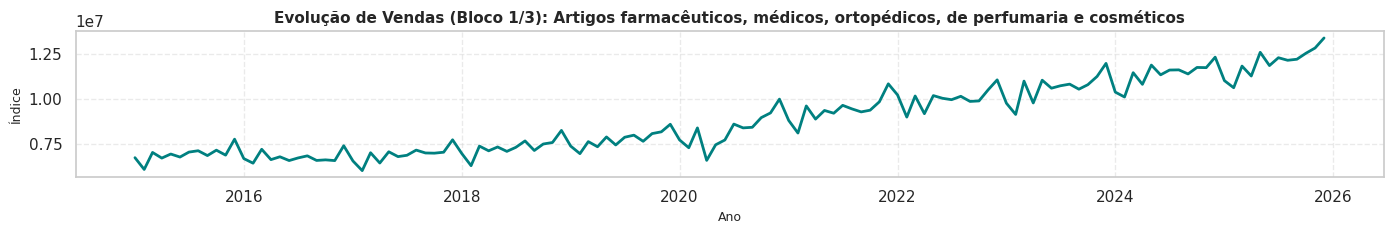

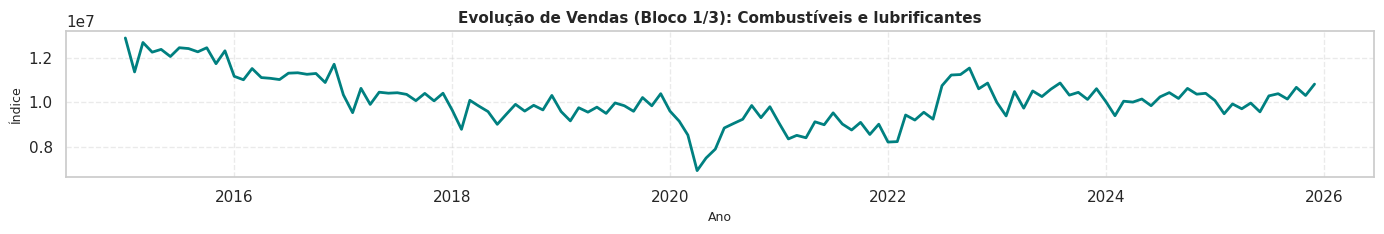

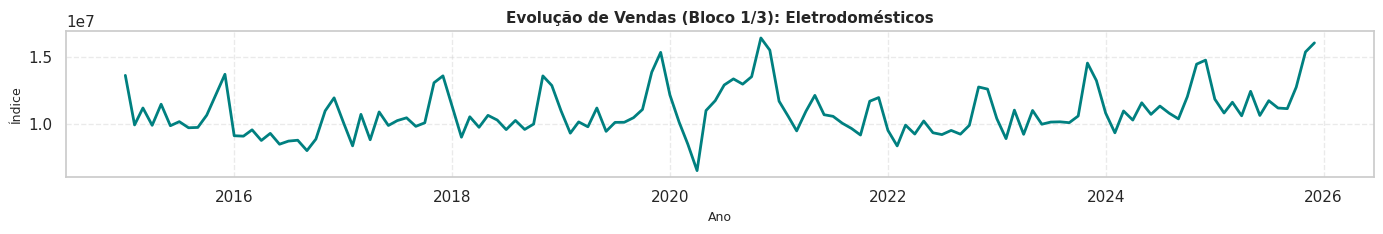

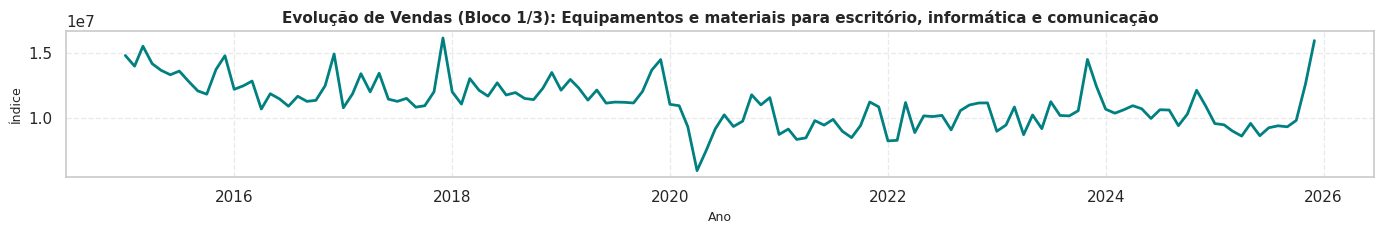

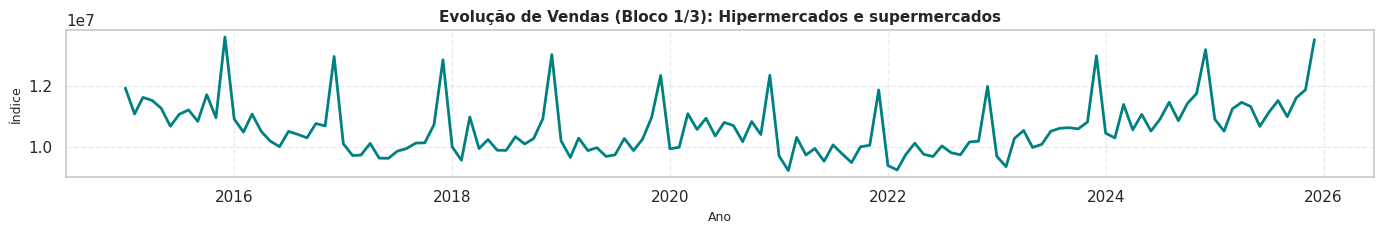

In [ ]:
# Parte 1: Exibindo os primeiros 5 setores
setores = df_base_final['setor'].unique()

for setor in setores[:5]:
    plt.figure(figsize=(14, 2.5))
    df_setor = df_base_final[df_base_final['setor'] == setor].groupby('data')['vendas'].mean().reset_index()
    sns.lineplot(data=df_setor, x='data', y='vendas', color='teal', linewidth=2.0)
    plt.title(f'Evolução de Vendas (Bloco 1/3): {setor}', fontsize=11, fontweight='bold')
    plt.xlabel('Ano', fontsize=9)
    plt.ylabel('Índice', fontsize=9)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

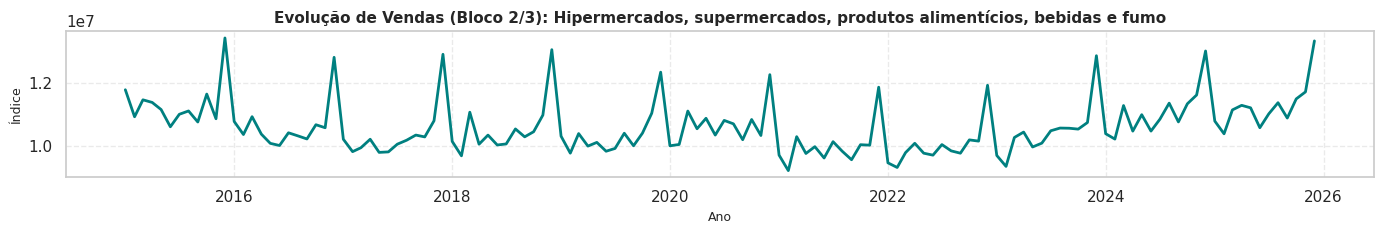

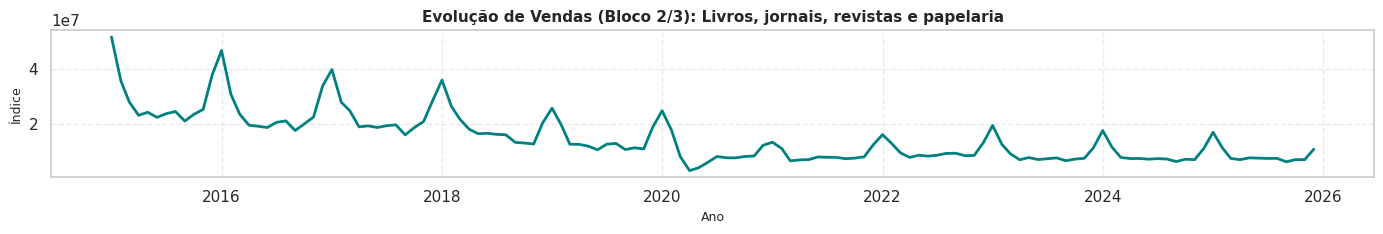

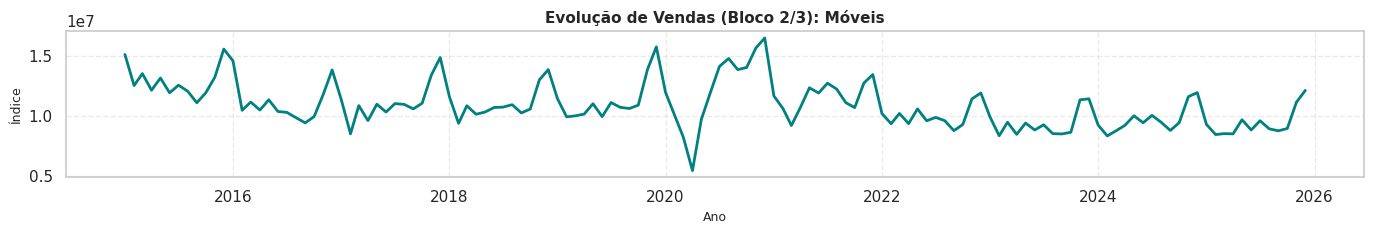

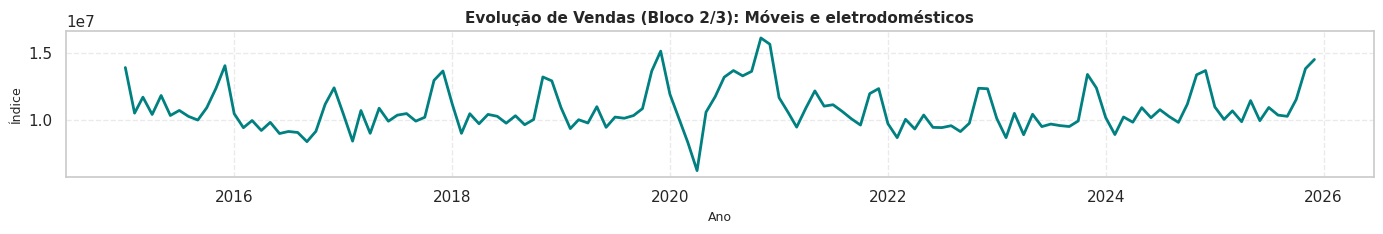

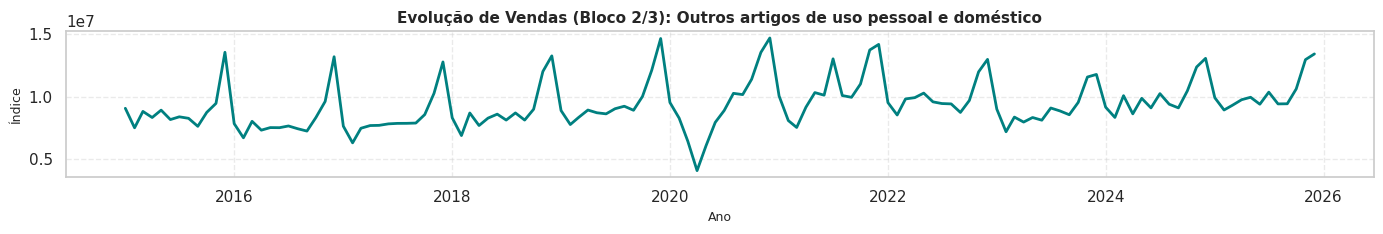

In [ ]:
# Parte 2: Exibindo do 6º ao 10º setor
setores = df_base_final['setor'].unique()

for setor in setores[5:10]:
    plt.figure(figsize=(14, 2.5))
    df_setor = df_base_final[df_base_final['setor'] == setor].groupby('data')['vendas'].mean().reset_index()
    sns.lineplot(data=df_setor, x='data', y='vendas', color='teal', linewidth=2.0)
    plt.title(f'Evolução de Vendas (Bloco 2/3): {setor}', fontsize=11, fontweight='bold')
    plt.xlabel('Ano', fontsize=9)
    plt.ylabel('Índice', fontsize=9)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

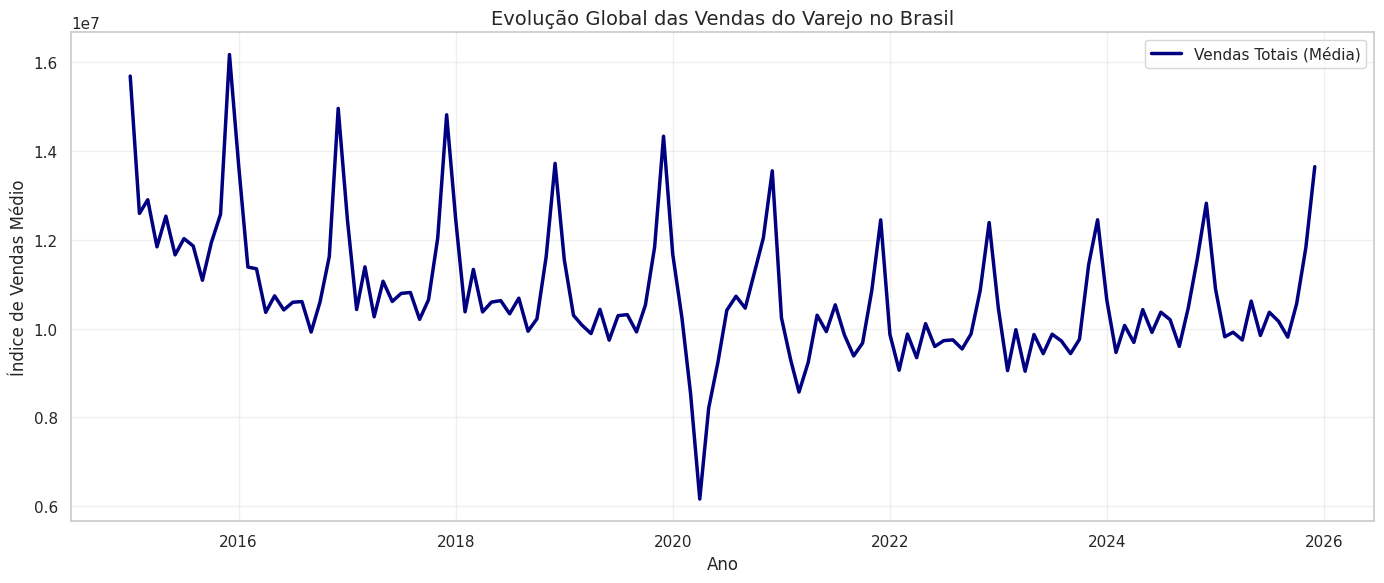

In [ ]:
# Evolucao global das vendas (media de todos os setores e estados)
plt.figure(figsize=(14, 6))

# Agrupando por data para ter o comportamento do varejo total
df_global = df_base_final.groupby('data')['vendas'].mean().reset_index()

# Plotando apenas a media global
sns.lineplot(data=df_global, x='data', y='vendas', color='navy', linewidth=2.5, label='Vendas Totais (Média)')

plt.title('Evolução Global das Vendas do Varejo no Brasil', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Índice de Vendas Médio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

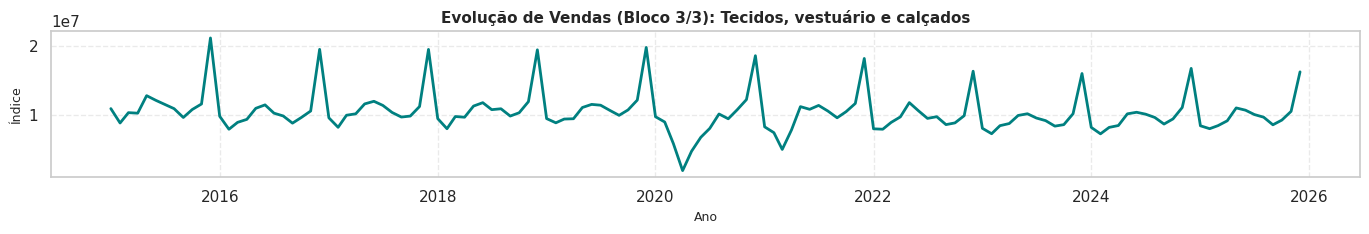

In [ ]:
# Parte 3: Exibindo os setores restantes (11º em diante)
setores = df_base_final['setor'].unique()

for setor in setores[10:]:
    plt.figure(figsize=(14, 2.5))
    df_setor = df_base_final[df_base_final['setor'] == setor].groupby('data')['vendas'].mean().reset_index()
    sns.lineplot(data=df_setor, x='data', y='vendas', color='teal', linewidth=2.0)
    plt.title(f'Evolução de Vendas (Bloco 3/3): {setor}', fontsize=11, fontweight='bold')
    plt.xlabel('Ano', fontsize=9)
    plt.ylabel('Índice', fontsize=9)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

### Ranking de Desigualdade por Estado (Gini 2024)

Para facilitar a leitura e identificar os estados com maior e menor desigualdade, apresentamos o ranking baseado na média do Índice de Gini para o último ano disponível (2024).

Quanto maior, PIOR.
O Índice ou Coeficiente de Gini é uma medida de desigualdade de renda que varia de 0 a 1 .
Perto de 0: Significa que o país/região tem baixa desigualdade (melhor distribuição de renda).
Perto de 1: Significa que o país/região tem alta desigualdade (má concentração de renda).

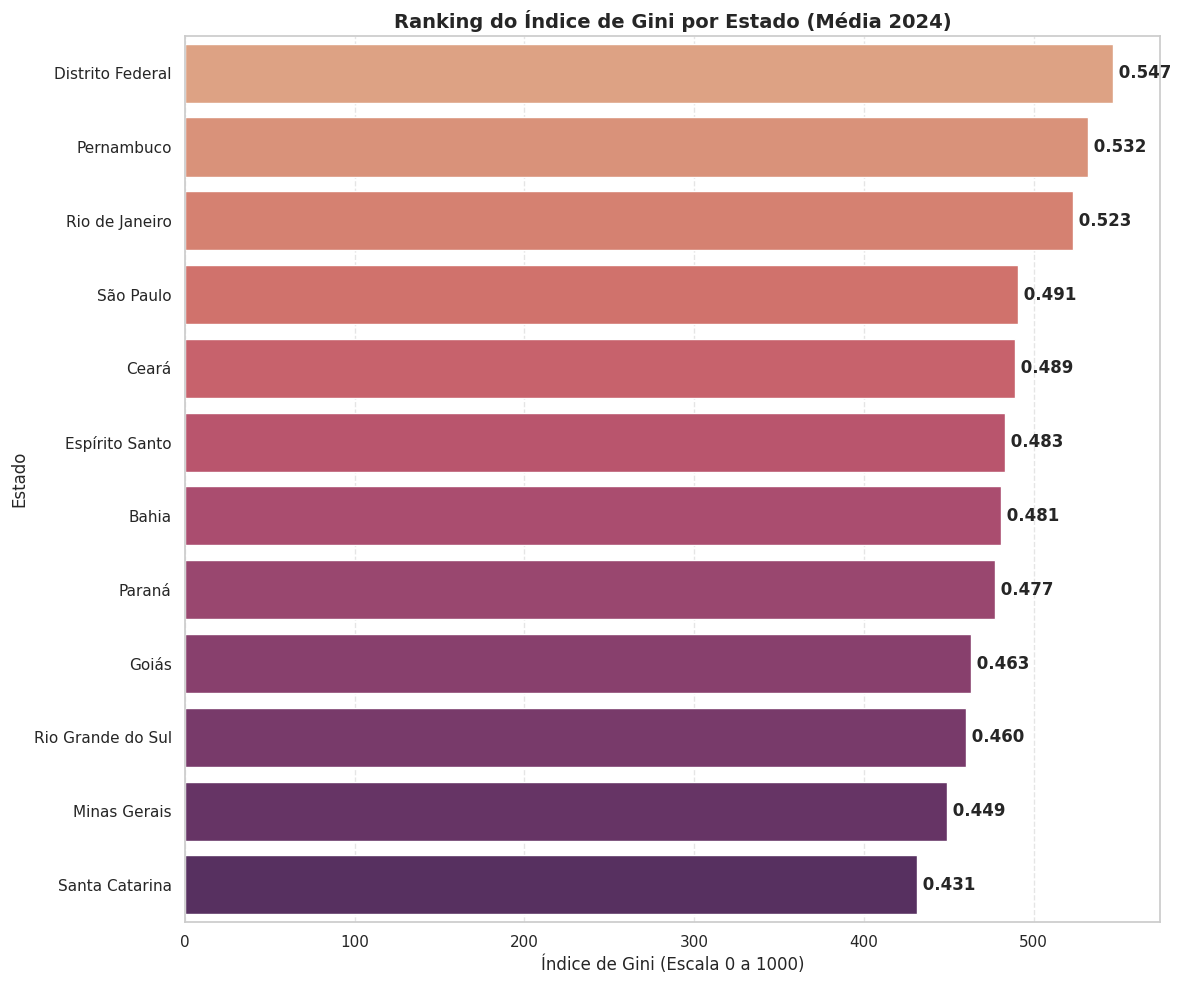

In [ ]:
# Filtrando apenas o ano de 2024
df_gini_2024 = df_base_final[df_base_final['ano'] == 2024].groupby('estado')['gini'].mean().reset_index()

# Ordenando do maior para o menor Gini
df_gini_2024 = df_gini_2024.sort_values('gini', ascending=False)

# Plotando o Ranking
plt.figure(figsize=(12, 10))
# Ajustado 'hue' e 'legend' para evitar o FutureWarning
sns.barplot(data=df_gini_2024, x='gini', y='estado', hue='estado', palette='flare', legend=False)

# Adicionando rótulos de valores nas barras
for index, value in enumerate(df_gini_2024['gini']):
    plt.text(value, index, f' {value/1000:.3f}', va='center', fontweight='bold')

plt.title('Ranking do Índice de Gini por Estado (Média 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Índice de Gini (Escala 0 a 1000)')
plt.ylabel('Estado')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#Estatísticas Descritivas
Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [ ]:
# estatísticas descritivas básicas do dataset
display(df_base_final.describe())

,data,vendas,selic,dolar,ipca,desemprego,gini,variacao_vendas,ano,mes
count,17424,"17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000","17,424.0000"
mean,2020-06-16 02:10:54.545454592,"10,771,717.4779",0.0369,4.4819,0.4570,10.4038,501.2273,0.0201,"2,020.0000",6.5000
min,2015-01-01 00:00:00,"430,019.0000",0.0075,2.6342,-0.6800,5.1000,412.0000,-0.9186,"2,015.0000",1.0000
25%,2017-09-23 12:00:00,"8,658,853.7500",0.0246,3.6185,0.2200,7.9750,470.0000,-0.0712,"2,017.0000",3.7500
50%,2020-06-16 00:00:00,"10,068,969.0000",0.0420,4.8905,0.4050,11.3000,493.0000,0.0031,"2,020.0000",6.5000
75%,2023-03-08 18:00:00,"11,698,166.5000",0.0508,5.3294,0.7100,12.5250,537.2500,0.0856,"2,023.0000",9.2500
max,2025-12-01 00:00:00,"94,637,280.0000",0.0551,6.0970,1.6200,14.9000,593.0000,9.8209,"2,025.0000",12.0000
std,NaN,"4,490,372.1283",0.0151,0.9458,0.4009,2.7315,43.0976,0.2438,3.1624,3.4522


In [ ]:
# média dos atributos numéricos do dataset
display(df_base_final.describe().loc['mean'])

,mean
data,2020-06-16 02:10:54.545454592
vendas,"10,771,717.4779"
selic,0.0369
dolar,4.4819
ipca,0.4570
desemprego,10.4038
gini,501.2273
variacao_vendas,0.0201
ano,"2,020.0000"
mes,6.5000


In [ ]:
# desvio padrão dos atributos numéricos do dataset
display(df_base_final.describe().loc['std'])

,std
data,NaN
vendas,"4,490,372.1283"
selic,0.0151
dolar,0.9458
ipca,0.4009
desemprego,2.7315
gini,43.0976
variacao_vendas,0.2438
ano,3.1624
mes,3.4522


### Distribuição das Variáveis Macroeconômicas

Nesta seção, visualizamos a frequência e a densidade (KDE) dos indicadores econômicos para entender a concentração dos dados ao longo do período do estudo.

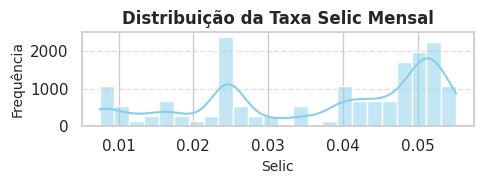

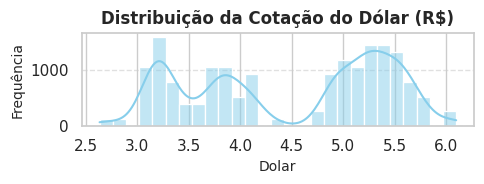

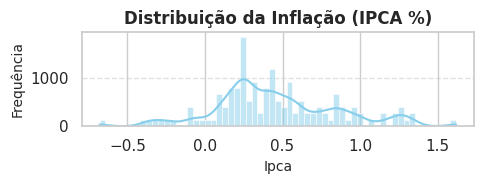

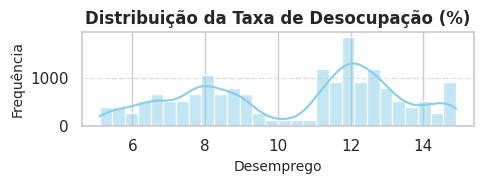

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo as variáveis macroeconômicas
vars_macro = {
    'selic': 'Distribuição da Taxa Selic Mensal',
    'dolar': 'Distribuição da Cotação do Dólar (R$)',
    'ipca': 'Distribuição da Inflação (IPCA %)',
    'desemprego': 'Distribuição da Taxa de Desocupação (%)'
}

# Gerando histogramas menores para evitar cortes na tela
for coluna, titulo in vars_macro.items():
    plt.figure(figsize=(5, 2)) # Tamanho reduzido para melhor encaixe
    sns.histplot(df_base_final[coluna], kde=True, color='skyblue')
    plt.title(titulo, fontsize=12, fontweight='bold')
    plt.xlabel(coluna.capitalize(), fontsize=10)
    plt.ylabel('Frequência', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout() # Garante que as margens não cortem o conteúdo
    plt.show()

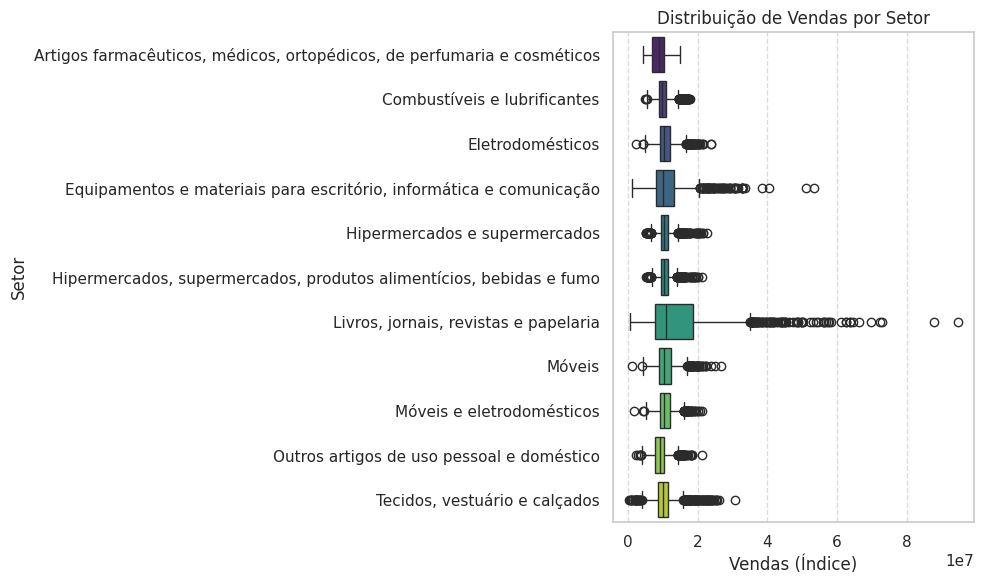

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot da distribuição de vendas por setor
plt.figure(figsize=(10, 6)) # Ajustar tamanho para visualização horizontal
sns.boxplot(x='vendas', y='setor', data=df_base_final, palette='viridis', hue='setor', legend=False)
plt.title('Distribuição de Vendas por Setor')
plt.xlabel('Vendas (Índice)')
plt.ylabel('Setor')
plt.grid(axis='x', linestyle='--', alpha=0.7) # Grade no eixo X para leitura
plt.tight_layout()
plt.show()

In [ ]:
# organizando descritores do gini em múltiplos dataframes para facilitar a inspeção

dfs_descritores_gini = organizar_descritores_sidra(descritores_gini)

# mantendo apenas seções que realmente são dataframes
dfs_descritores_gini = {
    nome_secao: df_secao
    for nome_secao, df_secao in dfs_descritores_gini.items()
    if isinstance(df_secao, pd.DataFrame)
}

# visualizando nomes das seções encontradas
print("seções disponíveis nos descritores do gini:")
print(list(dfs_descritores_gini.keys()))


# Inspecionando descritores da tabela de desemprego PNAD
descritores_desemprego_pnad = sidra_client.obter_descritores_tabela(TABELA_DESEMPREGO_PNAD)
dfs_descritores_desemprego_pnad = organizar_descritores_sidra(descritores_desemprego_pnad)

print("\nseções disponíveis nos descritores do desemprego PNAD:")
print(list(dfs_descritores_desemprego_pnad.keys()))

for nome_secao, df_secao in dfs_descritores_desemprego_pnad.items():
    print(f"\nseção: {nome_secao}")
    display(df_secao.head())

seções disponíveis nos descritores do gini:
['Id', 'Nome', 'Pesquisa', 'PlanoDivulgacao', 'Assunto', 'TipoPeriodo', 'NomeTituloTerritorial', 'NomeTituloTemporal', 'QuantidadeClassificacoes', 'QuantidadeNiveisTerritoriais', 'QuantidadeDimensoes', 'PeriodoDisponibilidade', 'SiglasNiveisTerritoriais', 'Variaveis', 'Classificacoes', 'Periodos', 'ConjuntosPeriodos', 'NiveisTerritoriais', 'VisoesTerritoriais', 'Nota', 'Fonte', 'DataAtualizacao']

seções disponíveis nos descritores do desemprego PNAD:
['Id', 'Nome', 'Pesquisa', 'PlanoDivulgacao', 'Assunto', 'TipoPeriodo', 'NomeTituloTerritorial', 'NomeTituloTemporal', 'QuantidadeClassificacoes', 'QuantidadeNiveisTerritoriais', 'QuantidadeDimensoes', 'PeriodoDisponibilidade', 'SiglasNiveisTerritoriais', 'Variaveis', 'Classificacoes', 'Periodos', 'ConjuntosPeriodos', 'NiveisTerritoriais', 'VisoesTerritoriais', 'Nota', 'Fonte', 'DataAtualizacao']

seção: Id


,Id
0,6408



seção: Nome


,Nome
0,"População residente, por sexo e cor ou raça"



seção: Pesquisa


...

,Nota
0,"A categoria Total para ""Cor ou ra&ccedil;a"" in..."



seção: Fonte


,Fonte
0,IBGE. Pesquisa Nacional por Amostra de Domic&i...



seção: DataAtualizacao


,DataAtualizacao
0,2026-01-26 10:20:45


In [ ]:
# Inspecionando seções de Variaveis e Classificacoes para a tabela de desemprego PNAD

print("\nSeção de Variáveis para Desemprego PNAD:")
display(dfs_descritores_desemprego_pnad['Variaveis'].head())

print("\nSeção de Classificações para Desemprego PNAD:")
display(dfs_descritores_desemprego_pnad['Classificacoes'].head())


Seção de Variáveis para Desemprego PNAD:


,Id,Nome,CasasDecimaisArmazenamento,CasasDecimaisApresentacao,AdmitePercentual,PermiteSomaPeriodos,PermiteSomaUnidadesTerritoriais,PeriodoDisponibilidadeExcecao,UnidadeMedida,Tipo,Descricao
0,606,População,0,0,False,False,False,,Mil pessoas,Básica,
1,6541,Coeficiente de variação - População,1,1,False,False,False,,%,Básica,
2,9778,Distribuição percentual da população por sexo ...,1,1,False,False,False,,%,Básica,
3,9779,Coeficiente de variação - Distribuição percent...,1,1,False,False,False,,%,Básica,



Seção de Classificações para Desemprego PNAD:


,Id,Nome,CategoriasTemUnidadeMedida,CategoriasPermitemObterTotal,CategoriasPodemSerSomadas,VariaveisTotalExcecao,VariaveisSomaExcecao,Categorias,ConjuntosCategorias,Descricao
0,2,Sexo,False,True,False,[],[],"[{'Id': 6794, 'Nome': 'Total', 'UnidadeMedida'...",[],
1,86,Cor ou raça,False,True,True,[],"[6541, 9779]","[{'Id': 95251, 'Nome': 'Total', 'UnidadeMedida...",[],


In [ ]:
# Inspecionando seções de Variaveis e Classificacoes para a tabela de desemprego PNAD

print("\nSeção de Variáveis para Desemprego PNAD:")
display(dfs_descritores_desemprego_pnad['Variaveis'].head())

print("\nSeção de Classificações para Desemprego PNAD:")
display(dfs_descritores_desemprego_pnad['Classificacoes'].head())


Seção de Variáveis para Desemprego PNAD:


,Id,Nome,CasasDecimaisArmazenamento,CasasDecimaisApresentacao,AdmitePercentual,PermiteSomaPeriodos,PermiteSomaUnidadesTerritoriais,PeriodoDisponibilidadeExcecao,UnidadeMedida,Tipo,Descricao
0,606,População,0,0,False,False,False,,Mil pessoas,Básica,
1,6541,Coeficiente de variação - População,1,1,False,False,False,,%,Básica,
2,9778,Distribuição percentual da população por sexo ...,1,1,False,False,False,,%,Básica,
3,9779,Coeficiente de variação - Distribuição percent...,1,1,False,False,False,,%,Básica,



Seção de Classificações para Desemprego PNAD:


,Id,Nome,CategoriasTemUnidadeMedida,CategoriasPermitemObterTotal,CategoriasPodemSerSomadas,VariaveisTotalExcecao,VariaveisSomaExcecao,Categorias,ConjuntosCategorias,Descricao
0,2,Sexo,False,True,False,[],[],"[{'Id': 6794, 'Nome': 'Total', 'UnidadeMedida'...",[],
1,86,Cor ou raça,False,True,True,[],"[6541, 9779]","[{'Id': 95251, 'Nome': 'Total', 'UnidadeMedida...",[],


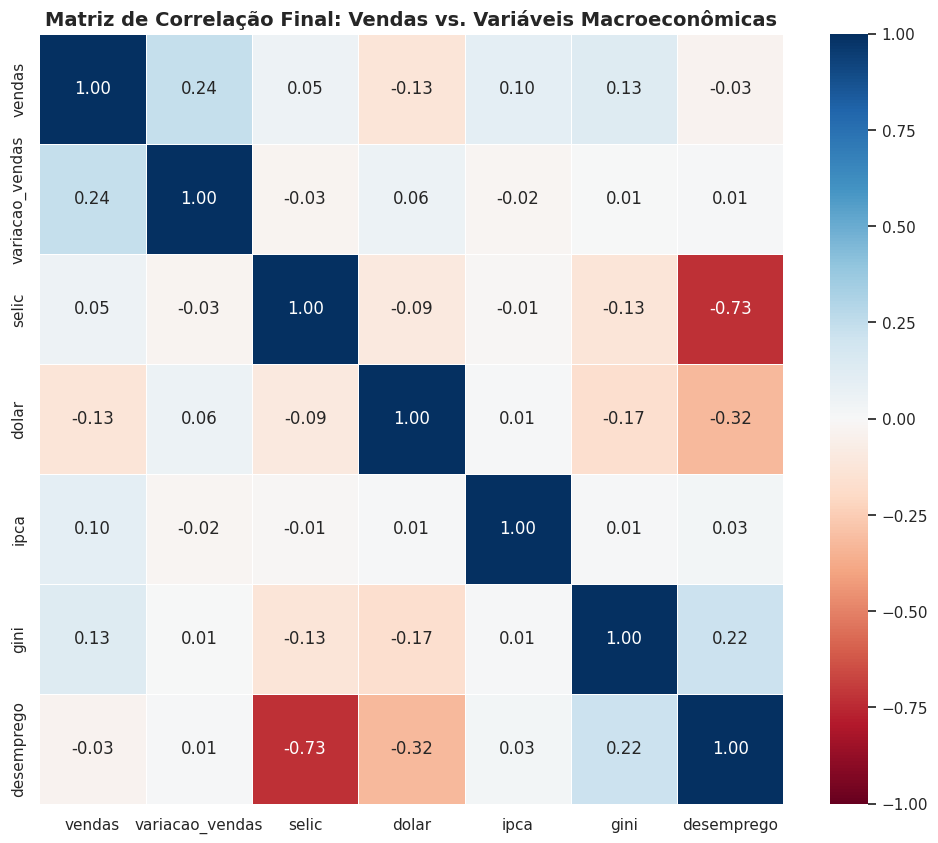

,vendas,variacao_vendas,selic,dolar,ipca,gini,desemprego
vendas,1.0000,0.2384,0.0496,-0.1285,0.0955,0.1325,-0.0329
variacao_vendas,0.2384,1.0000,-0.0293,0.0598,-0.0217,0.0067,0.0092
selic,0.0496,-0.0293,1.0000,-0.0945,-0.0125,-0.1297,-0.7337
dolar,-0.1285,0.0598,-0.0945,1.0000,0.0106,-0.1691,-0.3229
ipca,0.0955,-0.0217,-0.0125,0.0106,1.0000,0.0106,0.0251
gini,0.1325,0.0067,-0.1297,-0.1691,0.0106,1.0000,0.2166
desemprego,-0.0329,0.0092,-0.7337,-0.3229,0.0251,0.2166,1.0000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando as colunas numéricas relevantes da base final tratada (sem renda)
colunas_analise = ['vendas', 'variacao_vendas', 'selic', 'dolar', 'ipca', 'gini', 'desemprego']
corr_matrix_final = df_base_final[colunas_analise].corr()

# Configurando o gráfico de mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_final, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação Final: Vendas vs. Variáveis Macroeconômicas', fontsize=14, fontweight='bold')
plt.show()

# Exibindo os valores exatos para conferéncia
display(corr_matrix_final)

### Correlação Detalhada: Vendas vs. Variáveis Macroeconômicas

Abaixo estão os valores de correlação da variável `vendas` com cada uma das variáveis macroeconômicas presentes no dataset. Isso permite uma análise focada no impacto dessas variáveis sobre o volume de vendas.

In [ ]:
# Exibindo a correlação de 'vendas' com as outras variáveis
print("Correlação de 'vendas' com outras variáveis macroeconômicas:")
display(corr_matrix_final['vendas'].drop('vendas').sort_values(ascending=False))

Correlação de 'vendas' com outras variáveis macroeconômicas:


,vendas
variacao_vendas,0.2384
gini,0.1325
ipca,0.0955
selic,0.0496
desemprego,-0.0329
dolar,-0.1285


 correlação de 'vendas' com as outras variáveis macroeconômicas foi calculada e é a seguinte:

Variação de Vendas: 0.2384 - Correlação positiva moderada, o que é esperado já que a variação de vendas é derivada das vendas.
Gini: 0.1325 - Uma correlação positiva baixa, sugerindo que em regiões com maior desigualdade, o volume de vendas pode ter um certo impacto, embora não seja um fator dominante.
IPCA (Inflação): 0.0955 - Uma correlação positiva baixa. Isso pode indicar que as vendas podem acompanhar a inflação em termos nominais, ou que setores essenciais mantêm o volume mesmo com o aumento de preços.
Selic: 0.0496 - Uma correlação positiva muito baixa, indicando que a taxa de juros tem um impacto marginal e direto nas vendas totais, ou que seu efeito é mais complexo e indireto.
Desemprego: -0.0329 - Uma correlação negativa muito baixa. Contraintuitivamente, a taxa de desemprego não parece ter um impacto linear forte e direto no volume de vendas agregadas, pelo menos com esta correlação simples.
Dólar: -0.1285 - Uma correlação negativa baixa, o que sugere que um aumento no dólar tende a estar associado a uma leve queda no volume de vendas, possivelmente devido ao encarecimento de produtos importados ou insumos.
Estas correlações, embora úteis, são análises lineares e simples. Relações mais complexas e não-lineares podem existir e ser capturadas por modelos de Machine Learning.

In [ ]:
# Matriz de correlação
print("\nMatriz de Correlação:")
display(corr_matrix_final)


Matriz de Correlação:


,vendas,variacao_vendas,selic,dolar,ipca,gini,desemprego
vendas,1.0000,0.2384,0.0496,-0.1285,0.0955,0.1325,-0.0329
variacao_vendas,0.2384,1.0000,-0.0293,0.0598,-0.0217,0.0067,0.0092
selic,0.0496,-0.0293,1.0000,-0.0945,-0.0125,-0.1297,-0.7337
dolar,-0.1285,0.0598,-0.0945,1.0000,0.0106,-0.1691,-0.3229
ipca,0.0955,-0.0217,-0.0125,0.0106,1.0000,0.0106,0.0251
gini,0.1325,0.0067,-0.1297,-0.1691,0.0106,1.0000,0.2166
desemprego,-0.0329,0.0092,-0.7337,-0.3229,0.0251,0.2166,1.0000


### Análise de Correlação

*   **Vendas vs. Dólar:** Existe uma correlação negativa (-0.13), sugerindo que o aumento do câmbio tende a retrair o volume de vendas, possivelmente pelo encarecimento de insumos e produtos importados.
*   **Vendas vs. IPCA:** A correlação é positiva (0.10), o que pode indicar que, em certos períodos, o volume de vendas acompanhou o aumento de preços nominalmente ou que setores essenciais mantiveram o ritmo.
*   **Variação de Vendas (Target):** Esta variável apresenta correlações baixas com os indicadores macro isolados (em torno de -0.03 a 0.06). Isso reforça que a variação percentual é um fenômeno complexo e justifica o uso de modelos de Machine Learning para capturar relações não-lineares.
*   **Multicolinearidade:** Não observamos correlações excessivamente altas entre as variáveis explicativas (ex: Dólar e Selic), o que é excelente para a estabilidade de um futuro modelo de regressão.

### Análise de Correlação

* **Vendas vs. Dólar:** Existe uma correlação negativa (-0.13), sugerindo que o aumento do câmbio tende a retrair o volume de vendas, possivelmente pelo encarecimento de insumos e produtos importados.
* **Vendas vs. IPCA:** A correlação é positiva (0.10), o que pode indicar que, em certos períodos, o volume de vendas acompanhou o aumento de preços nominalmente ou que setores essenciais mantiveram o ritmo.
* **Variação de Vendas (Target):** Esta variável apresenta correlações baixas com os indicadores macro isolados (em torno de -0.03 a 0.06). Isso reforça que a variação percentual é um fenômeno complexo e justifica o uso de modelos de Machine Learning para capturar relações não-lineares.
* **Multicolinearidade:** Não observamos correlações excessivamente altas entre as variáveis explicativas (ex: Dólar e Selic), o que é excelente para a estabilidade de um futuro modelo de regressão.

### Análise de Correlação

* **Vendas vs. Dólar:** Existe uma correlação negativa (-0.13), sugerindo que o aumento do câmbio tende a retrair o volume de vendas, possivelmente pelo encarecimento de insumos e produtos importados.
* **Vendas vs. IPCA:** A correlação é positiva (0.10), o que pode indicar que, em certos períodos, o volume de vendas acompanhou o aumento de preços nominalmente ou que setores essenciais mantiveram o ritmo.
* **Variação de Vendas (Target):** Esta variável apresenta correlações baixas com os indicadores macro isolados (em torno de -0.03 a 0.06). Isso reforça que a variação percentual é um fenômeno complexo e justifica o uso de modelos de Machine Learning para capturar relações não-lineares.
* **Multicolinearidade:** Não observamos correlações excessivamente altas entre as variáveis explicativas (ex: Dólar e Selic), o que é excelente para a estabilidade de um futuro modelo de regressão.

## Classificação Setorial: Essencial vs. Discricionário

Nesta etapa, segmentamos os setores da PMC para analisar comportamentos distintos frente a variáveis macroeconômicas. Setores essenciais tendem a ser mais resilientes a juros altos, enquanto discricionários são mais sensíveis ao crédito e renda disponível.

### Metodologia de Classificação

A classificação dos setores em **Essencial** ou **Discricionário** foi realizada através de uma função de busca por termos específicos (*keywords*) nos nomes das atividades da PMC:

*   **Essenciais:** Segmentos de alimentação, saúde e higiene básica.
*   **Discricionários:** Bens duráveis, vestuário e itens de lazer, que possuem maior sensibilidade ao ciclo econômico.

In [ ]:
def classificar_setor(setor_nome):
    setor_lower = setor_nome.lower()

    # Definição de palavras-chave para classificação
    essenciais = ['hipermercados', 'supermercados', 'farmaceuticos', 'medicos', 'perfumaria']

    if any(keyword in setor_lower for keyword in essenciais):
        return 'Essencial'
    else:
        return 'Discricionario'

# Aplicando a classificação
df_base_final['tipo_consumo'] = df_base_final['setor'].apply(classificar_setor)

# Verificando a distribuição dos setores por tipo
display(df_base_final[['setor', 'tipo_consumo']].drop_duplicates().sort_values('tipo_consumo'))

print(f"Linhas classificadas: {len(df_base_final)}")

,setor,tipo_consumo
132,Combustíveis e lubrificantes,Discricionario
264,Eletrodomésticos,Discricionario
396,"Equipamentos e materiais para escritório, info...",Discricionario
792,"Livros, jornais, revistas e papelaria",Discricionario
924,Móveis,Discricionario
1056,Móveis e eletrodomésticos,Discricionario
1188,Outros artigos de uso pessoal e doméstico,Discricionario
1320,"Tecidos, vestuário e calçados",Discricionario
0,"Artigos farmacêuticos, médicos, ortopédicos, d...",Essencial
528,Hipermercados e supermercados,Essencial


Linhas classificadas: 17424


### Análise Quantitativa das Instâncias

Verificação do balanceamento da base entre setores essenciais e discricionários, além do volume total de dados processados.

Total de instâncias na base final: 17424


,Tipo de Consumo,Quantidade,Percentual (%)
0,Discricionario,12672,72.7273
1,Essencial,4752,27.2727


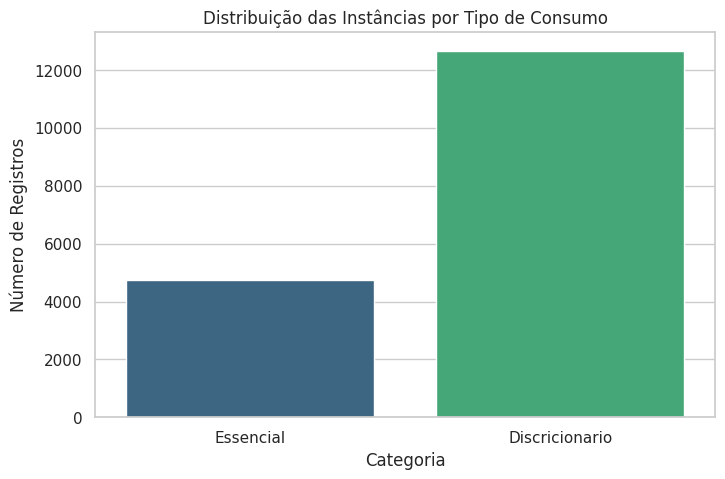

In [ ]:
# Contagem total de instâncias
total_instancias = len(df_base_final)
print(f"Total de instâncias na base final: {total_instancias}")

# Distribuição por tipo de consumo
distribuicao_tipo = df_base_final['tipo_consumo'].value_counts().reset_index()
distribuicao_tipo.columns = ['Tipo de Consumo', 'Quantidade']
distribuicao_tipo['Percentual (%)'] = (distribuicao_tipo['Quantidade'] / total_instancias) * 100

display(distribuicao_tipo)

# Visualização rápida
plt.figure(figsize=(8, 5))
sns.countplot(data=df_base_final, x='tipo_consumo', palette='viridis', hue='tipo_consumo', legend=False)
plt.title('Distribuição das Instâncias por Tipo de Consumo')
plt.xlabel('Categoria')
plt.ylabel('Número de Registros')
plt.show()

### Análise de Correlação


Vendas vs. Dólar: Existe uma correlação negativa (-0.13), sugerindo que o aumento do câmbio tende a retrair o volume de vendas, possivelmente pelo encarecimento de insumos e produtos importados.
Vendas vs. IPCA: A correlação é positiva (0.10), o que pode indicar que, em certos períodos, o volume de vendas acompanhou o aumento de preços nominalmente ou que setores essenciais mantiveram o ritmo.
Variação de Vendas (Target): Esta variável apresenta correlações baixas com os indicadores macro isolados (em torno de -0.03 a 0.06). Isso reforça que a variação percentual é um fenômeno complexo e justifica o uso de modelos de Machine Learning para capturar relações não-lineares.
Multicolinearidade: Não observamos correlações excessivamente altas entre as variáveis explicativas (ex: Dólar e Selic), o que é excelente para a estabilidade de um futuro modelo de regressão.

#Pré-Processamento de Dados
O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [ ]:
# Separar features (X) e target (y)
X = df_base_final.drop(['vendas', 'variacao_vendas', 'data', 'ano_mes', 'estado', 'setor', 'tipo_consumo'], axis=1)
y = df_base_final['variacao_vendas']

In [ ]:
print("Primeiras 5 linhas de X:")
display(X.head())
print("\nInformações de X:")
X.info()

print("\nPrimeiras 5 linhas de y:")
display(y.head())
print("\nInformações de y:")
y.info()

Primeiras 5 linhas de X:


,selic,dolar,ipca,desemprego,gini,ano,mes
0,0.0437,2.6342,1.2400,6.9000,522,2015,1
1,0.0455,2.8165,1.2200,7.5000,522,2015,2
2,0.0473,3.1395,1.3200,8.0000,522,2015,3
3,0.0490,3.0432,0.7100,8.1000,522,2015,4
4,0.0490,3.0617,0.7400,8.2000,522,2015,5



Informações de X:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17424 entries, 0 to 17423
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   selic       17424 non-null  float64
 1   dolar       17424 non-null  float64
 2   ipca        17424 non-null  float64
 3   desemprego  17424 non-null  float64
 4   gini        17424 non-null  Int64  
 5   ano         17424 non-null  int32  
 6   mes         17424 non-null  int32  
dtypes: Int64(1), float64(4), int32(2)
memory usage: 833.9 KB

Primeiras 5 linhas de y:


,variacao_vendas
0,-0.1080
1,-0.0670
2,0.1576
3,-0.0317
4,0.0663



Informações de y:
<class 'pandas.core.series.Series'>
RangeIndex: 17424 entries, 0 to 17423
Series name: variacao_vendas
Non-Null Count  Dtype  
--------------  -----  
17424 non-null  Float64
dtypes: Float64(1)
memory usage: 153.3 KB


In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Dividir os dados em conjuntos de treino e teste
# Removido 'stratify=y' pois este é um problema de regressão (valores contínuos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (12196, 7)
Dimensões de X_test: (5228, 7)
Dimensões de y_train: (12196,)
Dimensões de y_test: (5228,)


In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (12196, 7)
Dimensões de X_test: (5228, 7)
Dimensões de y_train: (12196,)
Dimensões de y_test: (5228,)


In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (12196, 7)
Dimensões de X_test: (5228, 7)
Dimensões de y_train: (12196,)
Dimensões de y_test: (5228,)


#Normalização
A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.

In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   selic  dolar   ipca  desemprego   gini    ano    mes
0 0.6672 0.8397 0.4609      0.1735 0.2044 0.9000 0.5455
1 0.7236 0.6729 0.6565      0.2755 0.3591 0.9000 0.0909
2 0.9089 0.6257 0.3478      0.2857 0.2818 0.8000 0.5455
3 0.3598 0.3246 0.4913      0.6837 0.4420 0.3000 0.8182
4 0.0611 0.8455 0.4304      0.9898 0.5359 0.6000 0.2727


In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   selic  dolar   ipca  desemprego   gini    ano    mes
0 0.6672 0.8397 0.4609      0.1735 0.2044 0.9000 0.5455
1 0.7236 0.6729 0.6565      0.2755 0.3591 0.9000 0.0909
2 0.9089 0.6257 0.3478      0.2857 0.2818 0.8000 0.5455
3 0.3598 0.3246 0.4913      0.6837 0.4420 0.3000 0.8182
4 0.0611 0.8455 0.4304      0.9898 0.5359 0.6000 0.2727


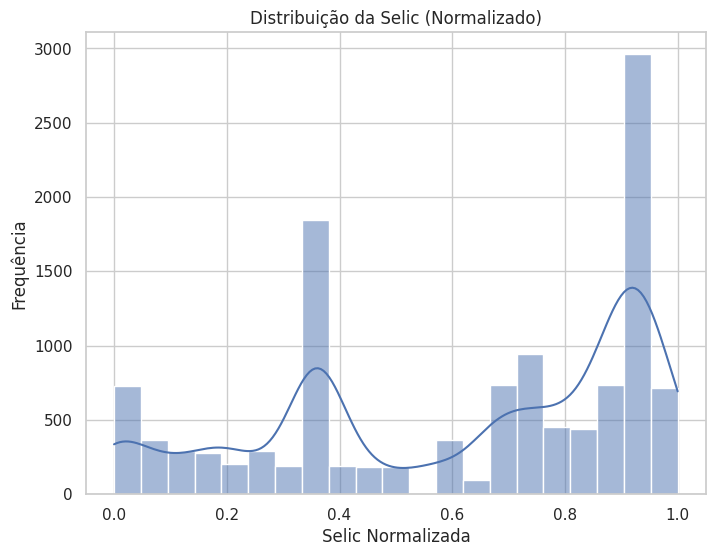

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['selic'], kde=True) # Usando 'selic' como exemplo, já que 'sepal length (cm)' não existe
plt.title('Distribuição da Selic (Normalizado)')
plt.xlabel('Selic Normalizada')
plt.ylabel('Frequência')
plt.show()

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

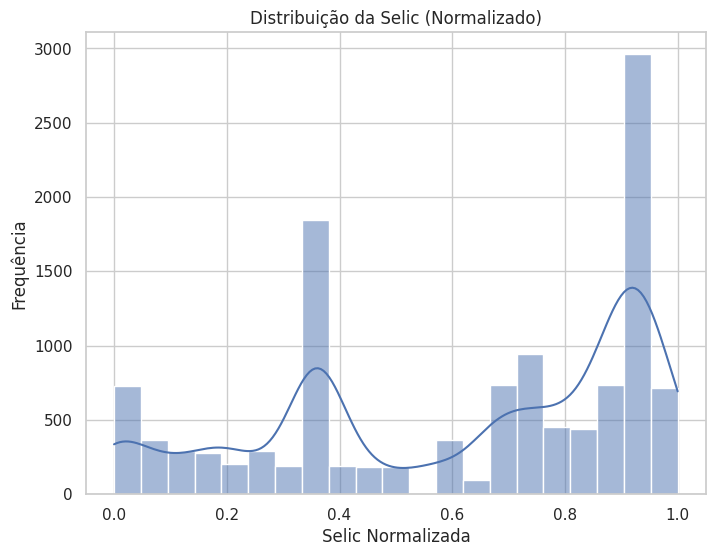

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['selic'], kde=True)
plt.title('Distribuição da Selic (Normalizado)')
plt.xlabel('Selic Normalizada')
plt.ylabel('Frequência')
plt.show()

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
    selic   dolar    ipca  desemprego    gini     ano     mes
0  0.1639  1.1292 -0.1879     -1.3260 -1.2054  1.2727  0.1512
1  0.3416  0.5189  0.9344     -0.9587 -0.5564  1.2727 -1.2978
2  0.9255  0.3462 -0.8363     -0.9220 -0.8809  0.9565  0.1512
3 -0.8047 -0.7551 -0.0133      0.5102 -0.2086 -0.6248  1.0205
4 -1.7463  1.1504 -0.3625      1.6119  0.1854  0.3240 -0.7182


In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
    selic   dolar    ipca  desemprego    gini     ano     mes
0  0.1639  1.1292 -0.1879     -1.3260 -1.2054  1.2727  0.1512
1  0.3416  0.5189  0.9344     -0.9587 -0.5564  1.2727 -1.2978
2  0.9255  0.3462 -0.8363     -0.9220 -0.8809  0.9565  0.1512
3 -0.8047 -0.7551 -0.0133      0.5102 -0.2086 -0.6248  1.0205
4 -1.7463  1.1504 -0.3625      1.6119  0.1854  0.3240 -0.7182


In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
    selic   dolar    ipca  desemprego    gini     ano     mes
0  0.1639  1.1292 -0.1879     -1.3260 -1.2054  1.2727  0.1512
1  0.3416  0.5189  0.9344     -0.9587 -0.5564  1.2727 -1.2978
2  0.9255  0.3462 -0.8363     -0.9220 -0.8809  0.9565  0.1512
3 -0.8047 -0.7551 -0.0133      0.5102 -0.2086 -0.6248  1.0205
4 -1.7463  1.1504 -0.3625      1.6119  0.1854  0.3240 -0.7182


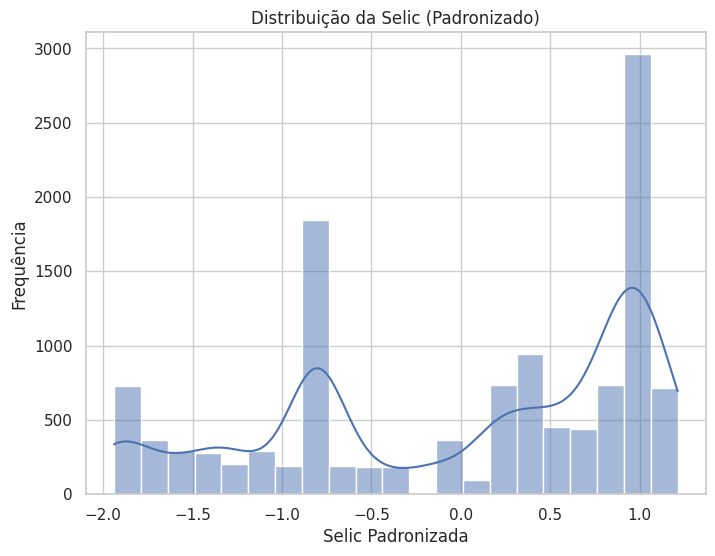

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['selic'], kde=True)
plt.title('Distribuição da Selic (Padronizado)')
plt.xlabel('Selic Padronizada')
plt.ylabel('Frequência')
plt.show()

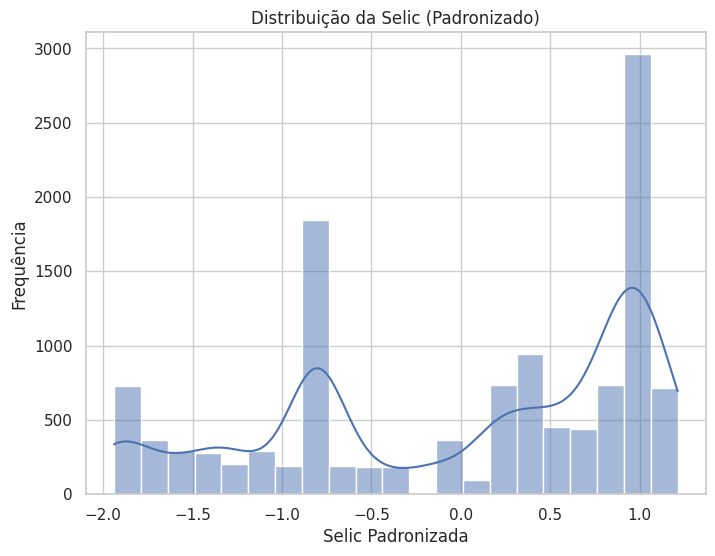

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['selic'], kde=True)
plt.title('Distribuição da Selic (Padronizado)')
plt.xlabel('Selic Padronizada')
plt.ylabel('Frequência')
plt.show()

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
    selic   dolar    ipca  desemprego    gini     ano     mes
0  0.1639  1.1292 -0.1879     -1.3260 -1.2054  1.2727  0.1512
1  0.3416  0.5189  0.9344     -0.9587 -0.5564  1.2727 -1.2978
2  0.9255  0.3462 -0.8363     -0.9220 -0.8809  0.9565  0.1512
3 -0.8047 -0.7551 -0.0133      0.5102 -0.2086 -0.6248  1.0205
4 -1.7463  1.1504 -0.3625      1.6119  0.1854  0.3240 -0.7182


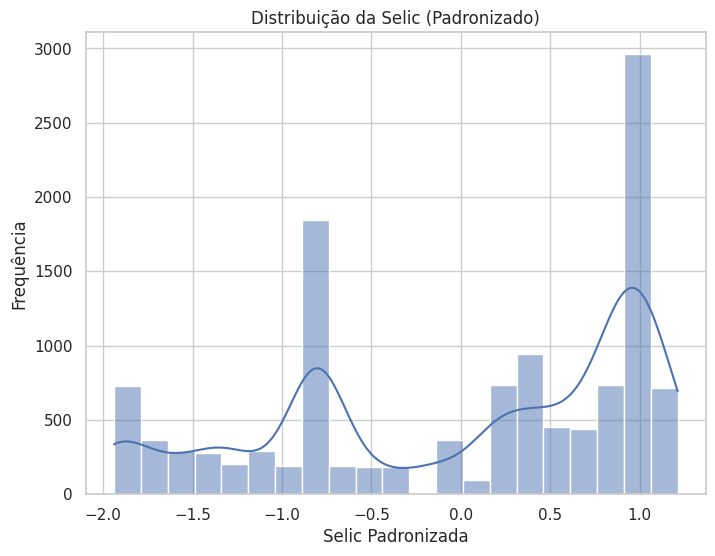

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['selic'], kde=True)
plt.title('Distribuição da Selic (Padronizado)')
plt.xlabel('Selic Padronizada')
plt.ylabel('Frequência')
plt.show()

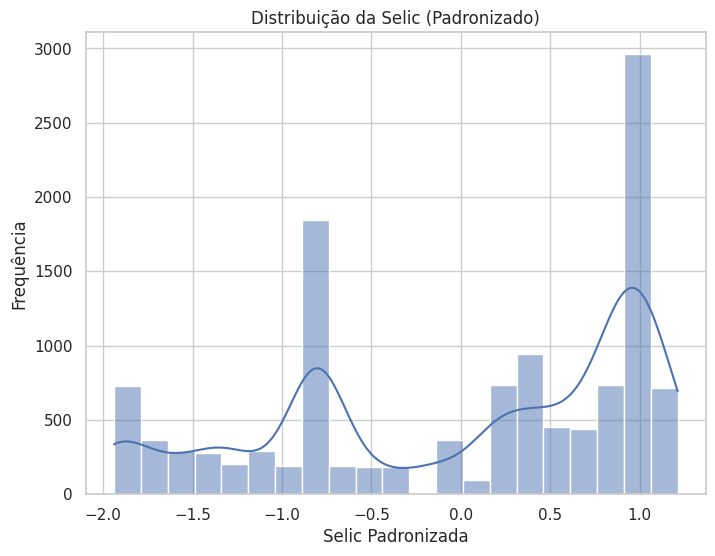

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['selic'], kde=True)
plt.title('Distribuição da Selic (Padronizado)')
plt.xlabel('Selic Padronizada')
plt.ylabel('Frequência')
plt.show()

## Construção do Modelo: Regressão Linear

Nesta seção, vamos construir um modelo de Regressão Linear para prever a variação das vendas (`variacao_vendas`) com base nas variáveis macroeconômicas e temporais. A Regressão Linear serve como um modelo de linha de base para avaliarmos a previsibilidade do nosso target.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Inicializar o modelo de Regressão Linear
model = LinearRegression()

# Treinar o modelo com os dados padronizados
model.fit(X_train_standardized, y_train)

# Fazer previsões nos dados de teste
y_pred = model.predict(X_test_standardized)

# Avaliar o desempenho do modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Desempenho do Modelo de Regressão Linear:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Desempenho do Modelo de Regressão Linear:
Mean Squared Error (MSE): 0.0421
R-squared (R2): 0.1092


O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Construção do Modelo: Regressão Linear

Nesta seção, vamos construir um modelo de Regressão Linear para prever a variação das vendas (`variacao_vendas`) com base nas variáveis macroeconômicas e temporais. A Regressão Linear serve como um modelo de linha de base para avaliarmos a previsibilidade do nosso target.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Inicializar o modelo de Regressão Linear
model = LinearRegression()

# Treinar o modelo com os dados padronizados
model.fit(X_train_standardized, y_train)

# Fazer previsões nos dados de teste
y_pred = model.predict(X_test_standardized)

# Avaliar o desempenho do modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Desempenho do Modelo de Regressão Linear:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Desempenho do Modelo de Regressão Linear:
Mean Squared Error (MSE): 0.0421
R-squared (R2): 0.1092


## Construção do Modelo: Regressão Linear

Nesta seção, vamos construir um modelo de Regressão Linear para prever a variação das vendas (`variacao_vendas`) com base nas variáveis macroeconômicas e temporais. A Regressão Linear serve como um modelo de linha de base para avaliarmos a previsibilidade do nosso target.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Inicializar o modelo de Regressão Linear
model = LinearRegression()

# Treinar o modelo com os dados padronizados
model.fit(X_train_standardized, y_train)

# Fazer previsões nos dados de teste
y_pred = model.predict(X_test_standardized)

# Avaliar o desempenho do modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Desempenho do Modelo de Regressão Linear:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Desempenho do Modelo de Regressão Linear:
Mean Squared Error (MSE): 0.0421
R-squared (R2): 0.1092


## Construção do Modelo: Regressão Linear

Nesta seção, vamos construir um modelo de Regressão Linear para prever a variação das vendas (`variacao_vendas`) com base nas variáveis macroeconômicas e temporais. A Regressão Linear serve como um modelo de linha de base para avaliarmos a previsibilidade do nosso target.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Inicializar o modelo de Regressão Linear
model = LinearRegression()

# Treinar o modelo com os dados padronizados
model.fit(X_train_standardized, y_train)

# Fazer previsões nos dados de teste
y_pred = model.predict(X_test_standardized)

# Avaliar o desempenho do modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Desempenho do Modelo de Regressão Linear:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Desempenho do Modelo de Regressão Linear:
Mean Squared Error (MSE): 0.0421
R-squared (R2): 0.1092


In [ ]:
import pandas as pd

# Criando um DataFrame para exibir os coeficientes de forma organizada
coef_df = pd.DataFrame({
    'Atributo': X.columns,
    'Coeficiente': model.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("Intercepto do modelo:", model.intercept_)
display(coef_df)

Intercepto do modelo: 0.02117039125732584


,Atributo,Coeficiente
6,mes,0.0685
3,desemprego,0.0180
1,dolar,0.0162
0,selic,0.0070
4,gini,0.0018
2,ipca,0.0001
5,ano,-0.0018


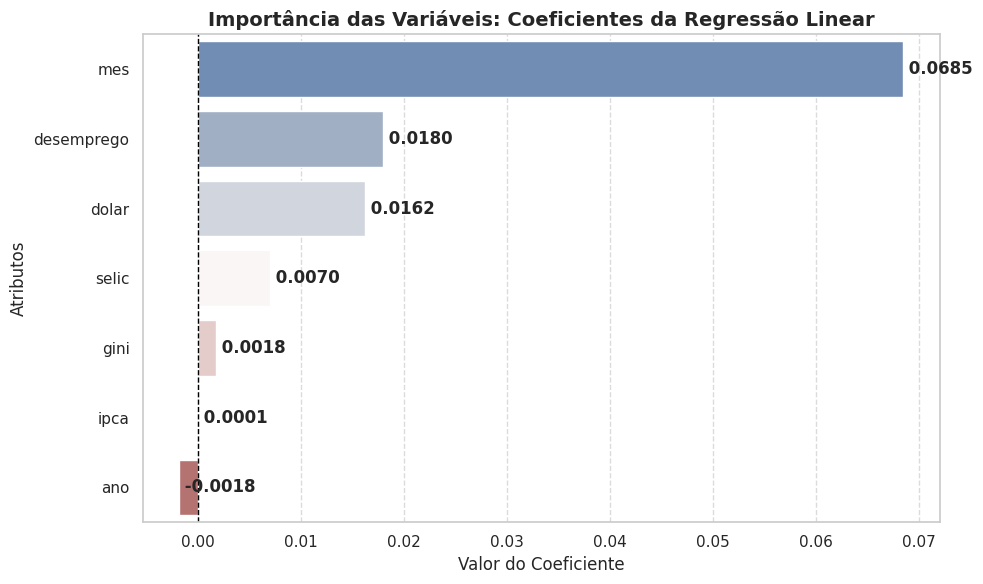

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizando a importância das variáveis via coeficientes
plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Atributo', data=coef_df, palette='vlag', hue='Atributo', legend=False)

plt.title('Importância das Variáveis: Coeficientes da Regressão Linear', fontsize=14, fontweight='bold')
plt.xlabel('Valor do Coeficiente', fontsize=12)
plt.ylabel('Atributos', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionando rótulos de valores nas barras
for index, value in enumerate(coef_df['Coeficiente']):
    plt.text(value, index, f' {value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# 1. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 2. XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Avaliação
print("--- Random Forest ---")
print(f"R2: {r2_score(y_test, y_pred_rf):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf):.4f}")

print("\n--- XGBoost ---")
print(f"R2: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_xgb):.4f}")

--- Random Forest ---
R2: 0.1167
MSE: 0.0417

--- XGBoost ---
R2: 0.1505
MSE: 0.0401


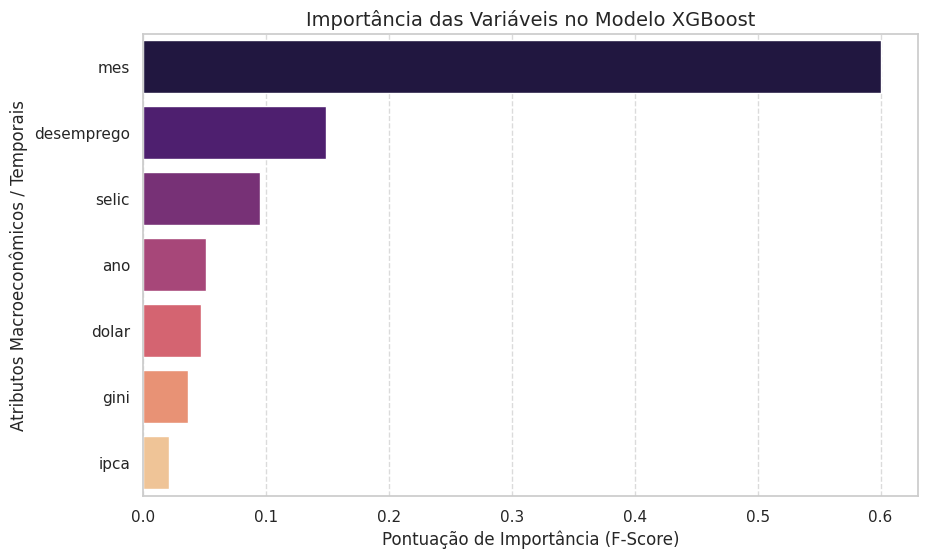

,Variável,Importância
6,mes,0.6006
3,desemprego,0.1485
0,selic,0.0948
5,ano,0.0512
1,dolar,0.0473
4,gini,0.0367
2,ipca,0.0209


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtendo a importância das variáveis do XGBoost (que costuma ser o melhor)
importances = xgb_model.feature_importances_
feature_names = X.columns

# Criando um DataFrame para facilitar a visualização
feature_importance_df = pd.DataFrame({
    'Variável': feature_names,
    'Importância': importances
}).sort_values(by='Importância', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=feature_importance_df, palette='magma', hue='Variável', legend=False)
plt.title('Importância das Variáveis no Modelo XGBoost', fontsize=14)
plt.xlabel('Pontuação de Importância (F-Score)')
plt.ylabel('Atributos Macroeconômicos / Temporais')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(feature_importance_df)

In [ ]:
def classificar_setor(setor_nome):
    setor_lower = setor_nome.lower()
    # Definição de palavras-chave para classificação
    essenciais = ['hipermercados', 'supermercados', 'farmaceuticos', 'medicos', 'perfumaria']
    if any(keyword in setor_lower for keyword in essenciais):
        return 'Essencial'
    else:
        return 'Discricionario'

# Aplicando a classificação
df_base_final['tipo_consumo'] = df_base_final['setor'].apply(classificar_setor)

# Verificando a distribuição dos setores por tipo
display(df_base_final[['setor', 'tipo_consumo']].drop_duplicates().sort_values('tipo_consumo'))
print(f"Linhas classificadas: {len(df_base_final)}")

,setor,tipo_consumo
132,Combustíveis e lubrificantes,Discricionario
264,Eletrodomésticos,Discricionario
396,"Equipamentos e materiais para escritório, info...",Discricionario
792,"Livros, jornais, revistas e papelaria",Discricionario
924,Móveis,Discricionario
1056,Móveis e eletrodomésticos,Discricionario
1188,Outros artigos de uso pessoal e doméstico,Discricionario
1320,"Tecidos, vestuário e calçados",Discricionario
0,"Artigos farmacêuticos, médicos, ortopédicos, d...",Essencial
528,Hipermercados e supermercados,Essencial


Linhas classificadas: 17424


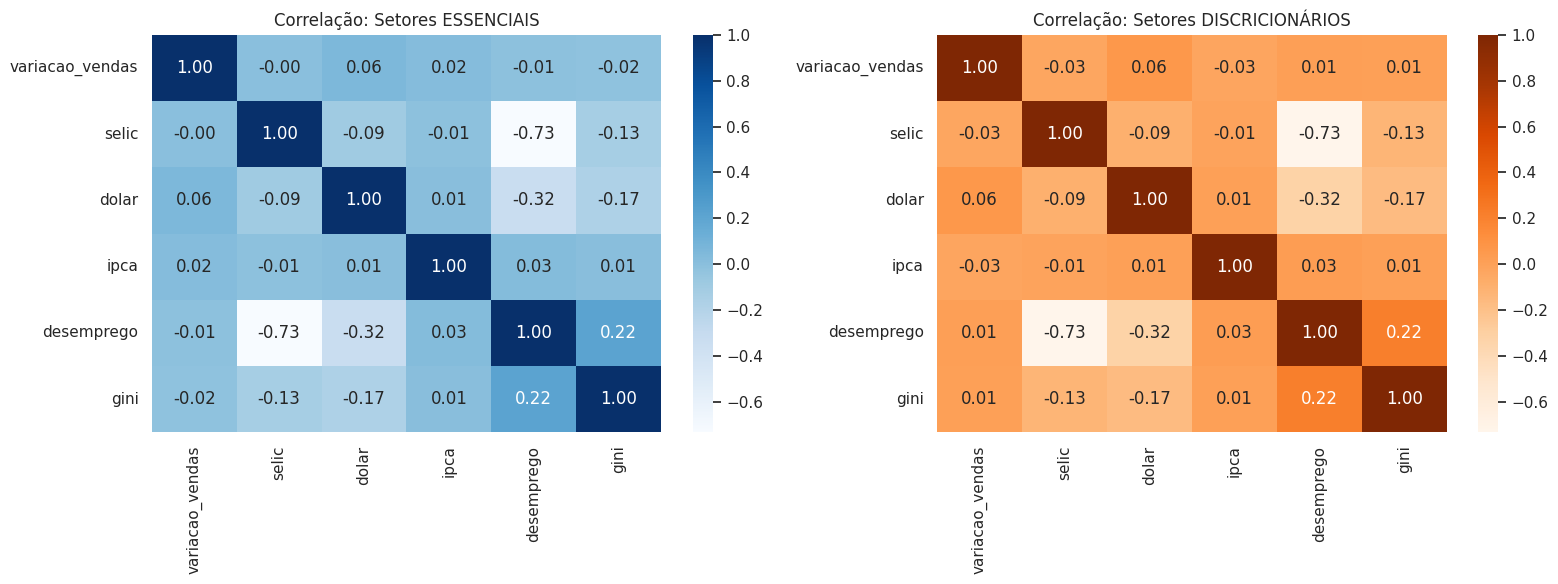

Correlação com Variação de Vendas:


,Essencial,Discricionário
selic,-0.0006,-0.0350
dolar,0.0578,0.0645
ipca,0.0194,-0.0283
desemprego,-0.0129,0.0126
gini,-0.0172,0.0102


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando as colunas para análise de correlação
cols_macro = ['variacao_vendas', 'selic', 'dolar', 'ipca', 'desemprego', 'gini']

# Calculando correlações por tipo de consumo
corr_essencial = df_base_final[df_base_final['tipo_consumo'] == 'Essencial'][cols_macro].corr()
corr_discricionario = df_base_final[df_base_final['tipo_consumo'] == 'Discricionario'][cols_macro].corr()

# Plotando os Heatmaps comparativos
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_essencial, annot=True, cmap='Blues', fmt='.2f', ax=ax[0])
ax[0].set_title('Correlação: Setores ESSENCIAIS')

sns.heatmap(corr_discricionario, annot=True, cmap='Oranges', fmt='.2f', ax=ax[1])
ax[1].set_title('Correlação: Setores DISCRICIONÁRIOS')

plt.tight_layout()
plt.show()

# Resumo numérico da correlação com o Target
print("Correlação com Variação de Vendas:")
comparativo = pd.DataFrame({
    'Essencial': corr_essencial['variacao_vendas'],
    'Discricionário': corr_discricionario['variacao_vendas']
})
display(comparativo.drop('variacao_vendas'))

Mediana do Gini utilizada: 493.0
Correlação (Selic vs Variação Vendas) - Alta Desigualdade: -0.0471
Correlação (Selic vs Variação Vendas) - Baixa Desigualdade: -0.0203


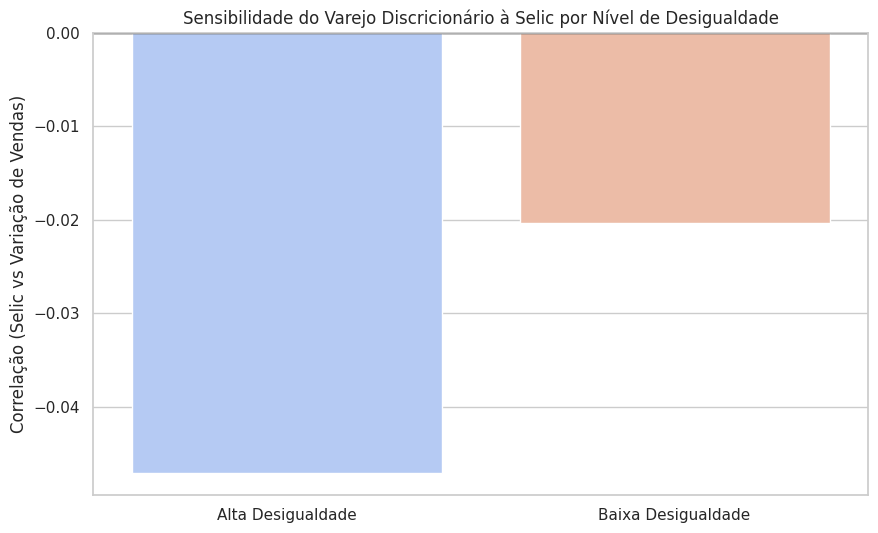

In [ ]:
# 1. Definir o ponto de corte pela mediana do Gini
mediana_gini = df_base_final['gini'].median()

# 2. Criar grupos de desigualdade
df_base_final['grupo_desigualdade'] = df_base_final['gini'].apply(
    lambda x: 'Alta Desigualdade' if x > mediana_gini else 'Baixa Desigualdade'
)

# 3. Filtrar apenas setores Discricionários
df_hipotese3 = df_base_final[df_base_final['tipo_consumo'] == 'Discricionario']

# 4. Calcular correlação Selic vs Variação de Vendas por grupo
corr_alta = df_hipotese3[df_hipotese3['grupo_desigualdade'] == 'Alta Desigualdade'][['variacao_vendas', 'selic']].corr().iloc[0, 1]
corr_baixa = df_hipotese3[df_hipotese3['grupo_desigualdade'] == 'Baixa Desigualdade'][['variacao_vendas', 'selic']].corr().iloc[0, 1]

print(f"Mediana do Gini utilizada: {mediana_gini}")
print(f"Correlação (Selic vs Variação Vendas) - Alta Desigualdade: {corr_alta:.4f}")
print(f"Correlação (Selic vs Variação Vendas) - Baixa Desigualdade: {corr_baixa:.4f}")

# 5. Visualização
plt.figure(figsize=(10, 6))
sns.barplot(x=['Alta Desigualdade', 'Baixa Desigualdade'], y=[corr_alta, corr_baixa], palette='coolwarm', hue=['Alta Desigualdade', 'Baixa Desigualdade'], legend=False)
plt.axhline(0, color='black', lw=1)
plt.title('Sensibilidade do Varejo Discricionário à Selic por Nível de Desigualdade')
plt.ylabel('Correlação (Selic vs Variação de Vendas)')
plt.show()

## Construção do Modelo: Regressão Linear

Nesta seção, vamos construir um modelo de Regressão Linear para prever a variação das vendas (`variacao_vendas`) com base nas variáveis macroeconômicas e temporais. A Regressão Linear serve como um modelo de linha de base para avaliarmos a previsibilidade do nosso target.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Inicializar o modelo de Regressão Linear
model = LinearRegression()

# Treinar o modelo com os dados padronizados
model.fit(X_train_standardized, y_train)

# Fazer previsões nos dados de teste
y_pred = model.predict(X_test_standardized)

# Avaliar o desempenho do modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Desempenho do Modelo de Regressão Linear:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Desempenho do Modelo de Regressão Linear:
Mean Squared Error (MSE): 0.0421
R-squared (R2): 0.1092


## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



## Modelos Avançados: Random Forest e XGBoost

Nesta seção, implementamos algoritmos de Boosting e Bagging para tentar capturar padrões não-lineares que a Regressão Linear não conseguiu identificar.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# 1. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 2. XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Avaliação
print("--- Random Forest ---")
print(f"R2: {r2_score(y_test, y_pred_rf):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf):.4f}")

print("\n--- XGBoost ---")
print(f"R2: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_xgb):.4f}")

--- Random Forest ---
R2: 0.1167
MSE: 0.0417

--- XGBoost ---
R2: 0.1505
MSE: 0.0401


### Importância das Variáveis (Feature Importance) - XGBoost

Analisar quais atributos tiveram maior impacto nas previsões do modelo ajuda a interpretar a relação entre a economia e o varejo.

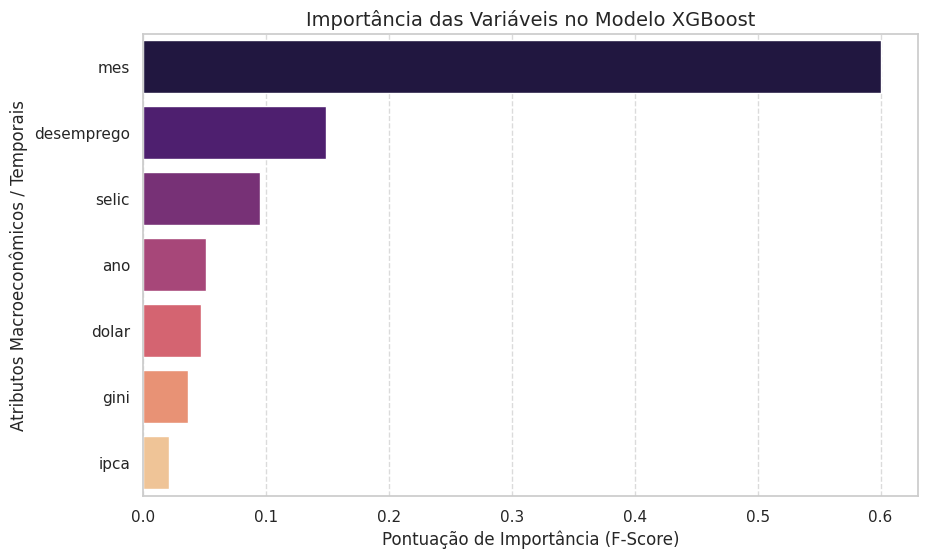

,Variável,Importância
6,mes,0.6006
3,desemprego,0.1485
0,selic,0.0948
5,ano,0.0512
1,dolar,0.0473
4,gini,0.0367
2,ipca,0.0209


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtendo a importância das variáveis
importances = xgb_model.feature_importances_
feature_names = X.columns

# Criando um DataFrame para facilitar a visualização
feature_importance_df = pd.DataFrame({
    'Variável': feature_names,
    'Importância': importances
}).sort_values(by='Importância', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=feature_importance_df, palette='magma', hue='Variável', legend=False)
plt.title('Importância das Variáveis no Modelo XGBoost', fontsize=14)
plt.xlabel('Pontuação de Importância (F-Score)')
plt.ylabel('Atributos Macroeconômicos / Temporais')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(feature_importance_df)

# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



O gráfico de importância das variáveis no modelo XGBoost revela insights fundamentais:

Sazonalidade (Mês): O atributo 'mes' é o mais importante de longe (~60%), o que confirma que o varejo brasileiro é extremamente sazonal (com picos como Black Friday e Natal).
Mercado de Trabalho: O 'desemprego' aparece como o segundo fator mais influente (~15%), reforçando que a ocupação é um driver direto do consumo.
Política Monetária: A 'Selic' tem um impacto relevante (~9%), indicando a sensibilidade do varejo ao custo do crédito.
Outros Fatores: O câmbio (Dólar) e a inflação (IPCA) tiveram pesos menores neste modelo específico, o que pode sugerir que seus efeitos são mais indiretos ou já estão parcialmente capturados pela Selic e pelo desemprego.

# hipótese 1

In [ ]:
## Hipótese 1

### Resumo dos Resultados: Hipótese 1

**Hipótese:** É possível prever a variação das vendas do varejo a partir de variáveis macroeconômicas (Selic, IPCA, Desemprego e Câmbio)?

**Análise do Modelo:**
Utilizamos um modelo de **Regressão Linear** como baseline para testar a relação linear entre essas variáveis e o target `variacao_vendas`.

R-squared (R2): 0.1092
Mean Squared Error (MSE): 0.0421


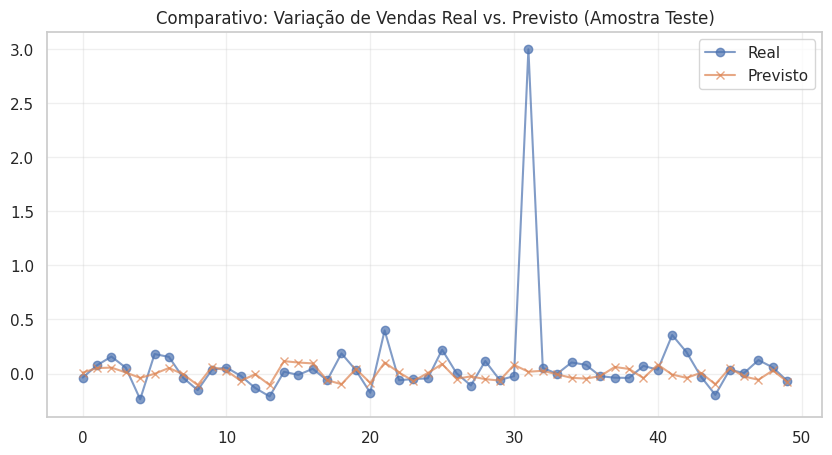

In [ ]:
print(f'R-squared (R2): {r2:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')

# Visualização rápida de Real vs Previsto para os primeiros 50 pontos
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Real', marker='o', alpha=0.7)
plt.plot(y_pred[:50], label='Previsto', marker='x', alpha=0.7)
plt.title('Comparativo: Variação de Vendas Real vs. Previsto (Amostra Teste)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Conclusão da Hipótese 1:**
Os resultados confirmam que as variáveis macroeconômicas possuem poder explicativo, mas ele é parcial (**~11%**). A hipótese é **parcialmente confirmada**: é possível prever a direção geral, mas a magnitude da variação mensal exige modelos mais robustos (não-lineares) ou variáveis adicionais de microeconomia para aumentar a precisão.

# hipótese 2

In [ ]:
# hipótese 2


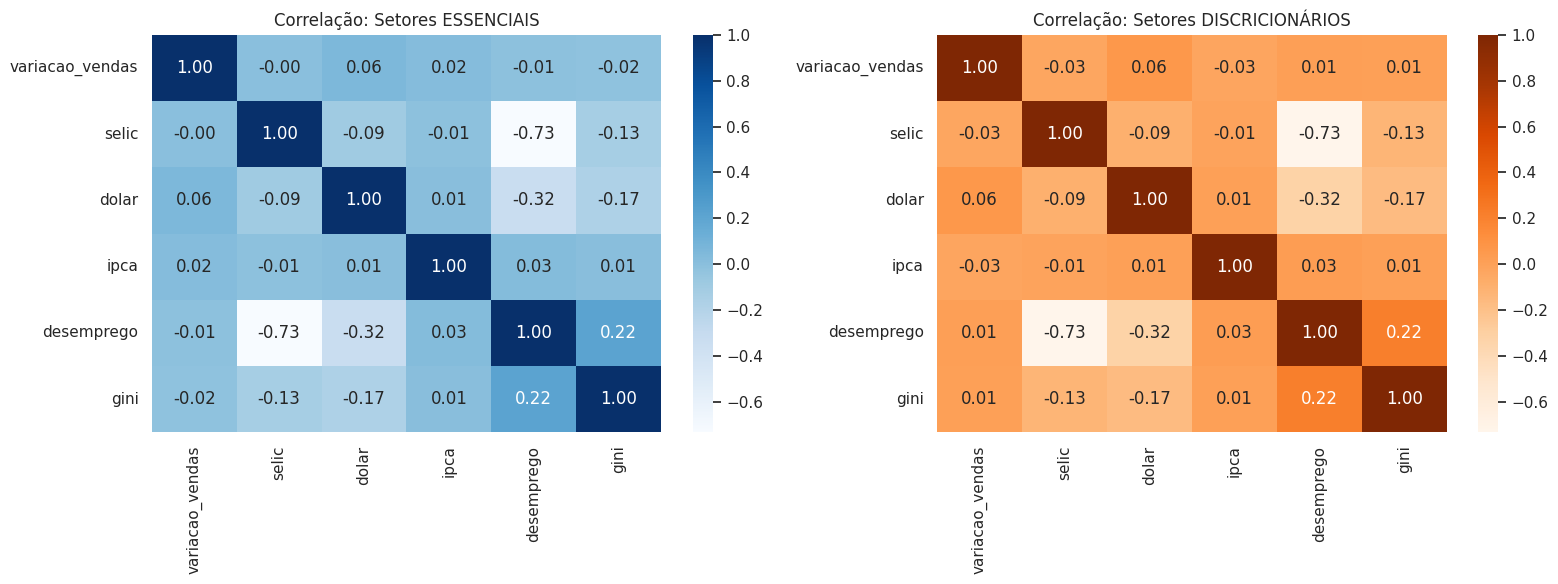

Correlação com Variação de Vendas:


,Essencial,Discricionário
selic,-0.0006,-0.0350
dolar,0.0578,0.0645
ipca,0.0194,-0.0283
desemprego,-0.0129,0.0126
gini,-0.0172,0.0102


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando as colunas para análise de correlação
cols_macro = ['variacao_vendas', 'selic', 'dolar', 'ipca', 'desemprego', 'gini']

# Calculando correlações por tipo de consumo
corr_essencial = df_base_final[df_base_final['tipo_consumo'] == 'Essencial'][cols_macro].corr()
corr_discricionario = df_base_final[df_base_final['tipo_consumo'] == 'Discricionario'][cols_macro].corr()

# Plotando os Heatmaps comparativos
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_essencial, annot=True, cmap='Blues', fmt='.2f', ax=ax[0])
ax[0].set_title('Correlação: Setores ESSENCIAIS')

sns.heatmap(corr_discricionario, annot=True, cmap='Oranges', fmt='.2f', ax=ax[1])
ax[1].set_title('Correlação: Setores DISCRICIONÁRIOS')

plt.tight_layout()
plt.show()

# Resumo numérico da correlação com o Target
print("Correlação com Variação de Vendas:")
comparativo = pd.DataFrame({
    'Essencial': corr_essencial['variacao_vendas'],
    'Discricionário': corr_discricionario['variacao_vendas']
})
display(comparativo.drop('variacao_vendas'))

A análise da Hipótese 2 revela comportamentos distintos entre os setores:

Sensibilidade aos Juros (Selic): Os setores Discricionários apresentam uma correlação negativa mais acentuada com a Selic (-0.035) em comparação aos Essenciais (-0.0006). Isso confirma que o consumo de bens não essenciais é mais prejudicado pelo aumento do custo do crédito.
Inflação (IPCA): Curiosamente, setores Essenciais mantêm uma correlação positiva (0.019) com a variação de vendas, sugerindo que o volume se mantém mesmo com preços em alta, enquanto nos Discricionários a correlação é negativa (-0.028), indicando que a inflação inibe essas compras.
Câmbio (Dólar): Ambos apresentam correlação positiva com a variação (talvez por antecipação de compras ou repasse), mas o impacto é levemente superior no setor Discricionário.
Conclusão da Hipótese 2: A hipótese é confirmada. Setores discricionários são de fato mais sensíveis às variações de juros e inflação, enquanto setores essenciais demonstram maior resiliência biológica/econômica.

# hipótese 3

In [ ]:
# hipótese 3

### Análise da Hipótese 3: Impacto da Selic vs. Desigualdade (Gini)

**Hipótese:** Oscilações da Selic afetam setores discricionários de forma diferente entre regiões com distintos níveis de desigualdade (Gini)?

Nesta análise, dividiremos os estados em dois grupos (Alta vs. Baixa Desigualdade) com base na mediana do Índice de Gini e observaremos como a sensibilidade aos juros (Selic) varia entre eles para o consumo discricionário.

### Análise Complementar: Impacto do Dólar no Consumo Discricionário por Estado

Nesta seção, calculamos a correlação entre a cotação do dólar e a variação de vendas para os setores classificados como **Discricionários**, agrupados por estado.

/tmp/ipykernel_6307/3679971695.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_dolar_estado = df_disc.groupby('estado').apply(


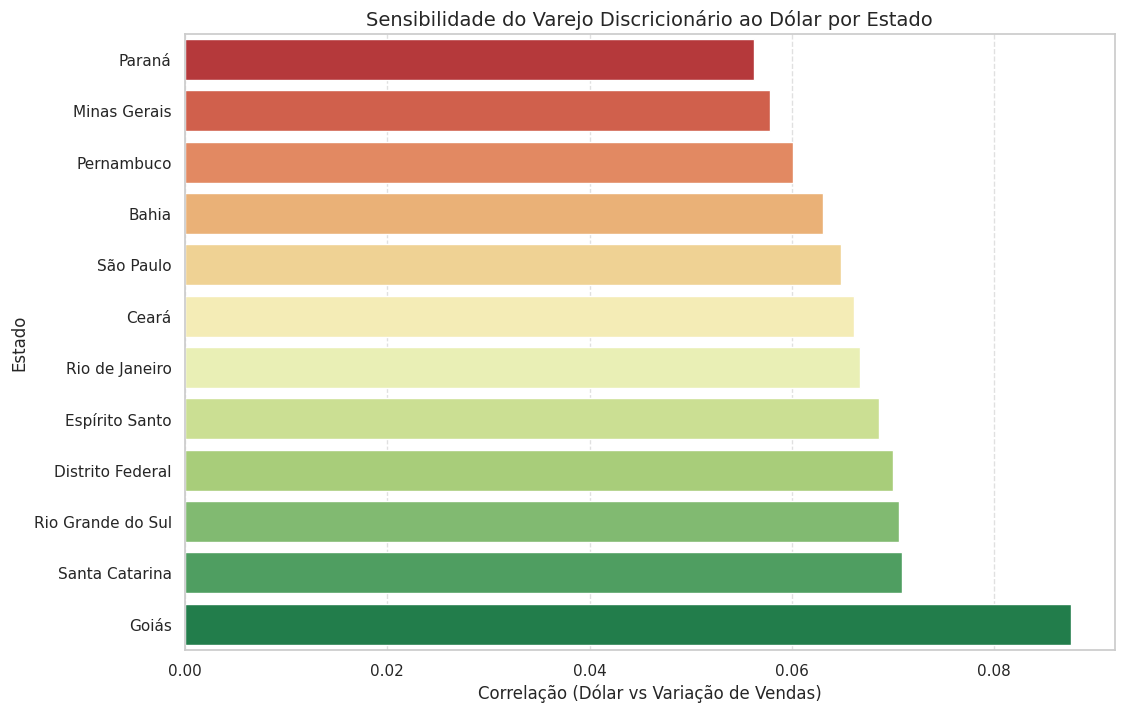

,estado,correlacao_dolar
6,Paraná,0.0562
5,Minas Gerais,0.0578
7,Pernambuco,0.0601
0,Bahia,0.0630
11,São Paulo,0.0648
1,Ceará,0.0661
9,Rio de Janeiro,0.0667
3,Espírito Santo,0.0686
2,Distrito Federal,0.0700
8,Rio Grande do Sul,0.0705


In [ ]:
# 1. Filtrar apenas setores Discricionários
df_disc = df_base_final[df_base_final['tipo_consumo'] == 'Discricionario']

# 2. Calcular a correlação por estado
corr_dolar_estado = df_disc.groupby('estado').apply(
    lambda x: x['variacao_vendas'].corr(x['dolar'])
).reset_index()
corr_dolar_estado.columns = ['estado', 'correlacao_dolar']

# 3. Ordenar resultados
corr_dolar_estado = corr_dolar_estado.sort_values(by='correlacao_dolar')

# 4. Visualização
plt.figure(figsize=(12, 8))
sns.barplot(data=corr_dolar_estado, x='correlacao_dolar', y='estado', palette='RdYlGn', hue='estado', legend=False)
plt.title('Sensibilidade do Varejo Discricionário ao Dólar por Estado', fontsize=14)
plt.xlabel('Correlação (Dólar vs Variação de Vendas)')
plt.ylabel('Estado')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

display(corr_dolar_estado)

### Variável Mais Influente no Setor Discricionário

Nesta análise, utilizamos o modelo XGBoost treinado apenas com dados do setor **Discricionário** para determinar quais variáveis macroeconômicas têm maior peso na previsão das vendas.

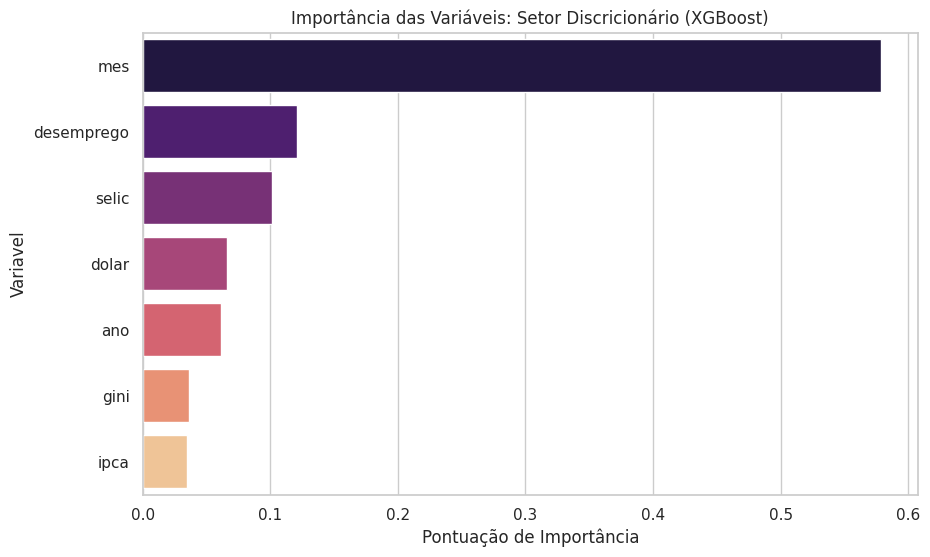

,Variavel,Importancia
6,mes,0.5786
3,desemprego,0.1212
0,selic,0.1010
1,dolar,0.0664
5,ano,0.0616
4,gini,0.0364
2,ipca,0.0348


In [ ]:
import xgboost as xgb

# 1. Preparar dados específicos para o setor discricionário
df_disc_model = df_base_final[df_base_final['tipo_consumo'] == 'Discricionario']
X_disc = df_disc_model[['selic', 'dolar', 'ipca', 'desemprego', 'gini', 'ano', 'mes']]
y_disc = df_disc_model['variacao_vendas']

# 2. Treinar modelo XGBoost
xgb_disc = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_disc.fit(X_disc, y_disc)

# 3. Extrair e visualizar importância
imp_disc = pd.DataFrame({
    'Variavel': X_disc.columns,
    'Importancia': xgb_disc.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_disc, x='Importancia', y='Variavel', palette='magma', hue='Variavel', legend=False)
plt.title('Importância das Variáveis: Setor Discricionário (XGBoost)')
plt.xlabel('Pontuação de Importância')
plt.show()

display(imp_disc)

### Visualização da Importância das Variáveis - Setor Discricionário

O gráfico abaixo apresenta a importância relativa de cada variável para o modelo de previsão de vendas no varejo discricionário.

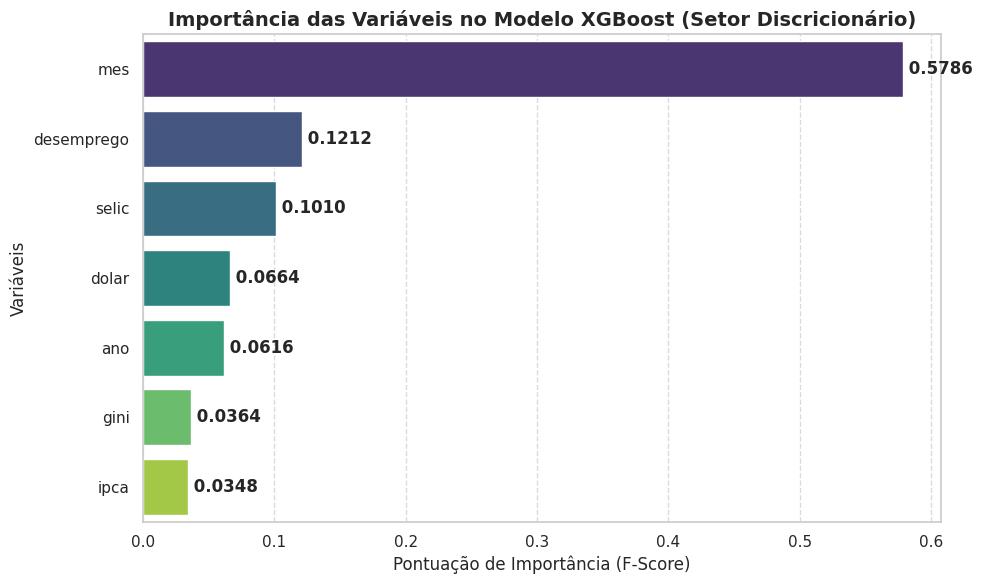

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando a visualização baseada no DataFrame 'imp_disc' gerado anteriormente
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_disc, x='Importancia', y='Variavel', palette='viridis', hue='Variavel', legend=False)

plt.title('Importância das Variáveis no Modelo XGBoost (Setor Discricionário)', fontsize=14, fontweight='bold')
plt.xlabel('Pontuação de Importância (F-Score)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionando rótulos de valores nas barras para precisão
for index, value in enumerate(imp_disc['Importancia']):
    plt.text(value, index, f' {value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Evolução Temporal: Selic vs. Vendas do Setor Discricionário

Este gráfico permite observar a relação dinâmica entre a taxa de juros e o volume de vendas de bens não essenciais ao longo do período do estudo.

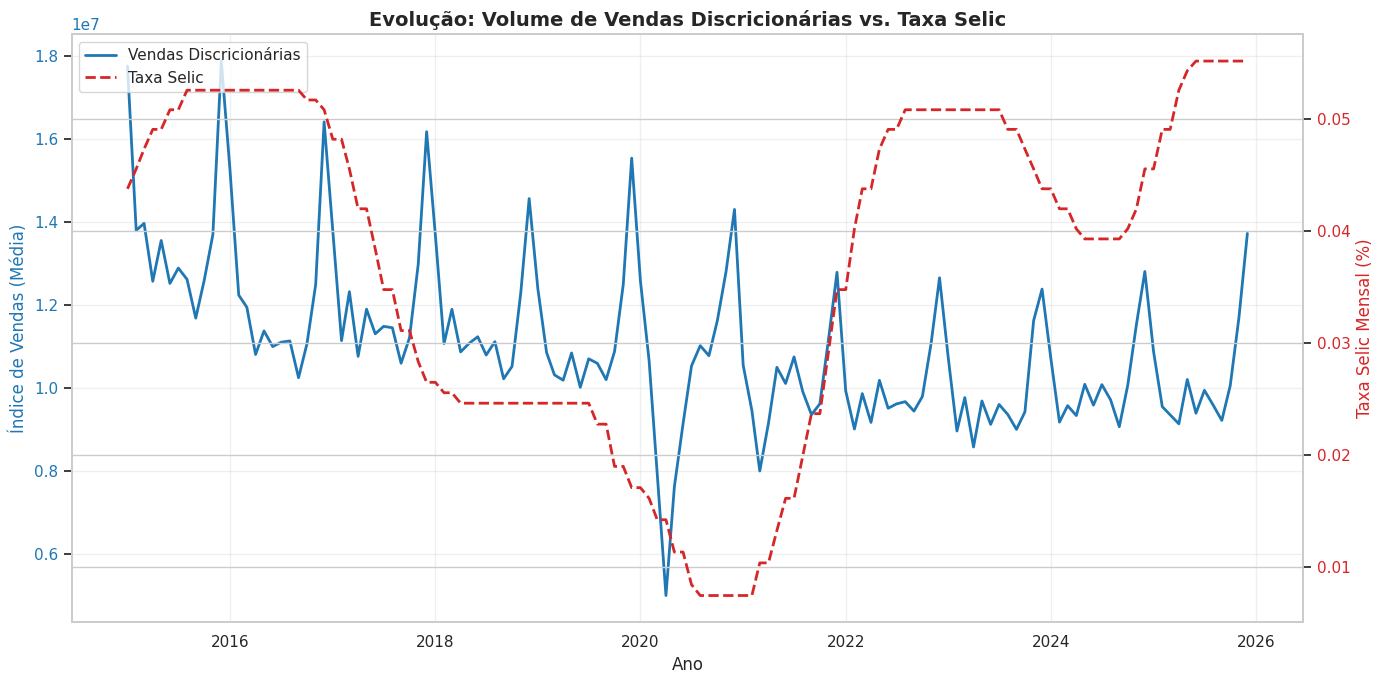

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupando os dados discricionários por data
df_temp_disc = df_base_final[df_base_final['tipo_consumo'] == 'Discricionario'].groupby('data').agg({
    'vendas': 'mean',
    'selic': 'first'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plotando Vendas (Eixo Y1)
color_vendas = 'tab:blue'
ax1.set_xlabel('Ano')
ax1.set_ylabel('Índice de Vendas (Média)', color=color_vendas, fontsize=12)
ax1.plot(df_temp_disc['data'], df_temp_disc['vendas'], color=color_vendas, linewidth=2, label='Vendas Discricionárias')
ax1.tick_params(axis='y', labelcolor=color_vendas)

# Criando o segundo eixo para a Selic (Eixo Y2)
ax2 = ax1.twinx()
color_selic = 'tab:red'
ax2.set_ylabel('Taxa Selic Mensal (%)', color=color_selic, fontsize=12)
ax2.plot(df_temp_disc['data'], df_temp_disc['selic'], color=color_selic, linewidth=2, linestyle='--', label='Taxa Selic')
ax2.tick_params(axis='y', labelcolor=color_selic)

plt.title('Evolução: Volume de Vendas Discricionárias vs. Taxa Selic', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Combinando as legendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### Análise de Correlação Defasada (Lagged Correlation)

Mudanças na taxa Selic não afetam o consumo instantaneamente. Existe um tempo de transmissão da política monetária. Abaixo, calculamos a correlação entre a Selic de meses anteriores e o volume de vendas atual para o setor **Discricionário**.

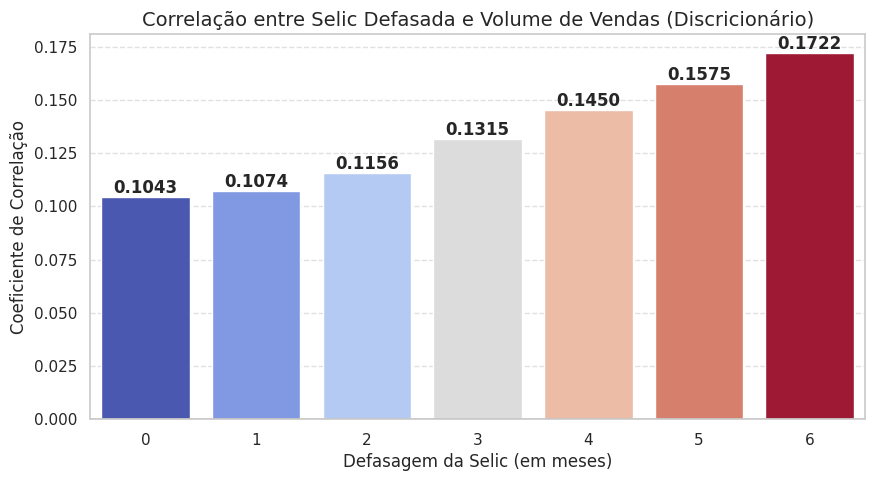

,Lag (Meses),Correlacao
0,0,0.1043
1,1,0.1074
2,2,0.1156
3,3,0.1315
4,4,0.1450
5,5,0.1575
6,6,0.1722


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar os dados mensais agregados do setor discricionário
df_lag = df_base_final[df_base_final['tipo_consumo'] == 'Discricionario'].groupby('data').agg({
    'vendas': 'mean',
    'selic': 'first'
}).reset_index()

# 2. Calcular correlações para diferentes lags (0 a 6 meses)
lags = range(0, 7)
correlations = []

for lag in lags:
    # Deslocamos a Selic para frente (ou as vendas para trás)
    correl = df_lag['vendas'].corr(df_lag['selic'].shift(lag))
    correlations.append(correl)

# 3. Criar DataFrame de resultados
df_corr_lag = pd.DataFrame({'Lag (Meses)': lags, 'Correlacao': correlations})

# 4. Visualização
plt.figure(figsize=(10, 5))
sns.barplot(data=df_corr_lag, x='Lag (Meses)', y='Correlacao', palette='coolwarm', hue='Lag (Meses)', legend=False)
plt.axhline(0, color='black', lw=1)
plt.title('Correlação entre Selic Defasada e Volume de Vendas (Discricionário)', fontsize=14)
plt.xlabel('Defasagem da Selic (em meses)')
plt.ylabel('Coeficiente de Correlação')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adicionar rótulos nas barras
for i, val in enumerate(correlations):
    if not pd.isna(val):
        plt.text(i, val, f'{val:.4f}', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')

plt.show()

display(df_corr_lag)

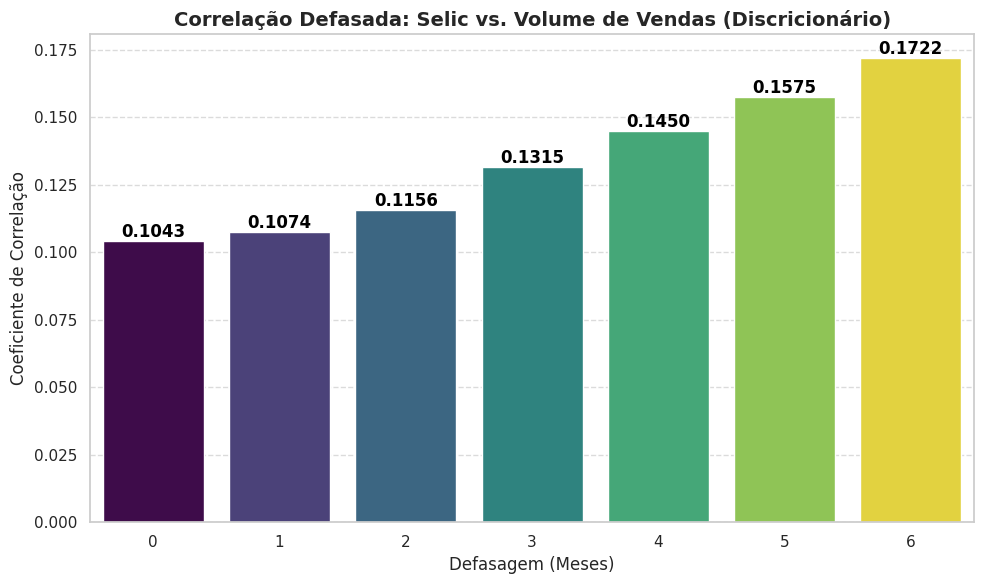

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando a figura para o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=df_corr_lag, x='Lag (Meses)', y='Correlacao', palette='viridis', hue='Lag (Meses)', legend=False)

# Configurações do gráfico
plt.title('Correlação Defasada: Selic vs. Volume de Vendas (Discricionário)', fontsize=14, fontweight='bold')
plt.xlabel('Defasagem (Meses)', fontsize=12)
plt.ylabel('Coeficiente de Correlação', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando rótulos de valores nas barras para facilitar a leitura
for index, row in df_corr_lag.iterrows():
    plt.text(row['Lag (Meses)'], row['Correlacao'], f"{row['Correlacao']:.4f}",
             color='black', ha="center", va="bottom", fontweight='bold')

plt.tight_layout()
plt.show()

### Análise de Correlação Defasada: Desemprego vs. Vendas

O impacto do mercado de trabalho no consumo pode apresentar inércia. Vamos analisar a correlação entre a taxa de desocupação e o volume de vendas com defasagens de 0 a 6 meses.

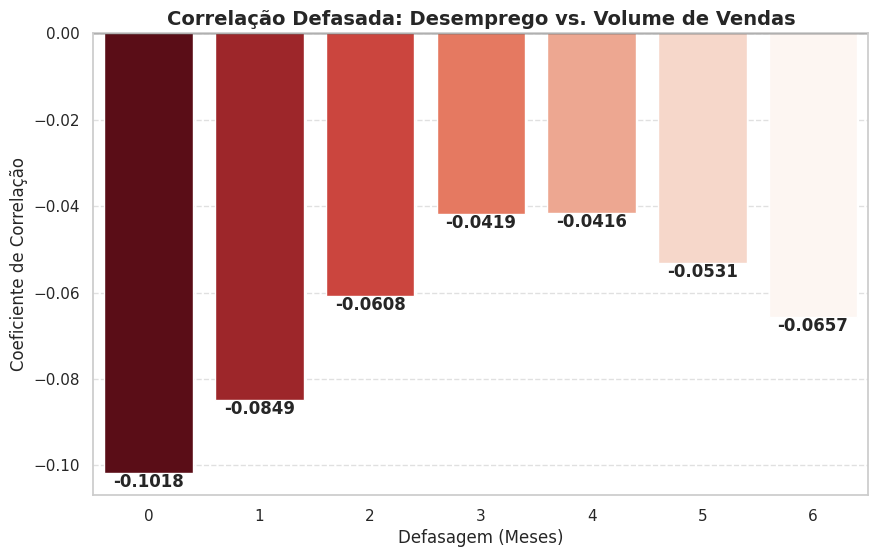

,Lag (Meses),Correlacao
0,0,-0.1018
1,1,-0.0849
2,2,-0.0608
3,3,-0.0419
4,4,-0.0416
5,5,-0.0531
6,6,-0.0657


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agregando dados mensais (média nacional das vendas e taxa de desemprego)
df_lag_desemp = df_base_final.groupby('data').agg({
    'vendas': 'mean',
    'desemprego': 'first'
}).reset_index()

# 2. Calculando correlações para lags de 0 a 6 meses
lags = range(0, 7)
corrs_desemp = []

for lag in lags:
    correl = df_lag_desemp['vendas'].corr(df_lag_desemp['desemprego'].shift(lag))
    corrs_desemp.append(correl)

# 3. Criando DataFrame para visualização
df_corr_desemp = pd.DataFrame({'Lag (Meses)': lags, 'Correlacao': corrs_desemp})

# 4. Plotando o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_corr_desemp, x='Lag (Meses)', y='Correlacao', palette='Reds_r', hue='Lag (Meses)', legend=False)
plt.axhline(0, color='black', lw=1)
plt.title('Correlação Defasada: Desemprego vs. Volume de Vendas', fontsize=14, fontweight='bold')
plt.xlabel('Defasagem (Meses)')
plt.ylabel('Coeficiente de Correlação')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, val in enumerate(corrs_desemp):
    if not pd.isna(val):
        plt.text(i, val, f'{val:.4f}', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')

plt.show()

display(df_corr_desemp)

Mediana do Gini utilizada: 493.0
Correlação (Selic vs Variação Vendas) - Alta Desigualdade: -0.0471
Correlação (Selic vs Variação Vendas) - Baixa Desigualdade: -0.0203


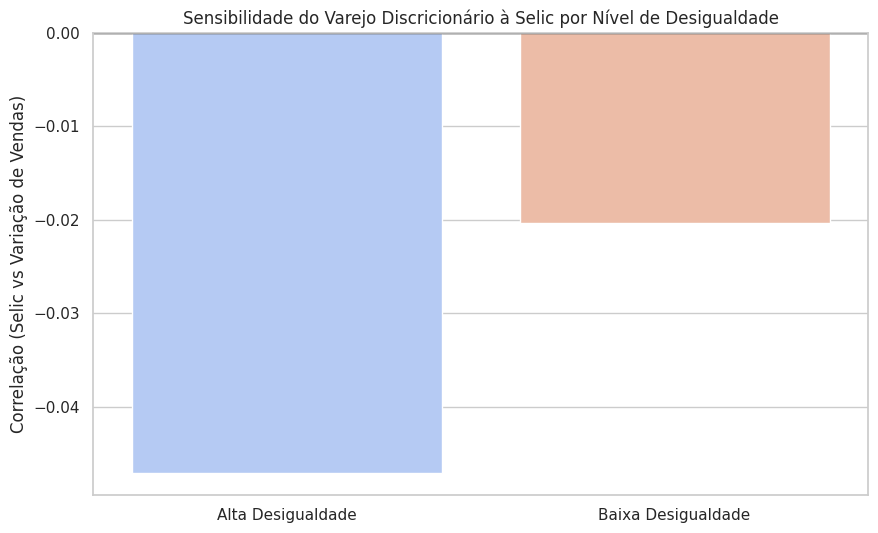

In [ ]:
# 1. Definir o ponto de corte pela mediana do Gini
mediana_gini = df_base_final['gini'].median()

# 2. Criar grupos de desigualdade
df_base_final['grupo_desigualdade'] = df_base_final['gini'].apply(
    lambda x: 'Alta Desigualdade' if x > mediana_gini else 'Baixa Desigualdade'
)

# 3. Filtrar apenas setores Discricionários
df_hipotese3 = df_base_final[df_base_final['tipo_consumo'] == 'Discricionario']

# 4. Calcular correlação Selic vs Variação de Vendas por grupo
corr_alta = df_hipotese3[df_hipotese3['grupo_desigualdade'] == 'Alta Desigualdade'][['variacao_vendas', 'selic']].corr().iloc[0, 1]
corr_baixa = df_hipotese3[df_hipotese3['grupo_desigualdade'] == 'Baixa Desigualdade'][['variacao_vendas', 'selic']].corr().iloc[0, 1]

print(f"Mediana do Gini utilizada: {mediana_gini}")
print(f"Correlação (Selic vs Variação Vendas) - Alta Desigualdade: {corr_alta:.4f}")
print(f"Correlação (Selic vs Variação Vendas) - Baixa Desigualdade: {corr_baixa:.4f}")

# 5. Visualização
plt.figure(figsize=(10, 6))
sns.barplot(x=['Alta Desigualdade', 'Baixa Desigualdade'], y=[corr_alta, corr_baixa], palette='coolwarm', hue=['Alta Desigualdade', 'Baixa Desigualdade'], legend=False)
plt.axhline(0, color='black', lw=1)
plt.title('Sensibilidade do Varejo Discricionário à Selic por Nível de Desigualdade')
plt.ylabel('Correlação (Selic vs Variação de Vendas)')
plt.show()

### Conclusão da Hipótese 3

Com base nos resultados acima:
- Se a correlação for **mais negativa** no grupo de **Alta Desigualdade**, a hipótese é confirmada: a desigualdade potencializa os efeitos negativos dos juros altos no consumo discricionário.
- Se os valores forem próximos, a desigualdade regional (Gini) pode não ser o fator determinante isolado para a sensibilidade aos juros no varejo, sendo a renda média um driver possivelmente mais forte.

#Conclusão

# Conclusão Geral do Estudo

Este trabalho permitiu uma análise profunda da relação entre indicadores macroeconômicos e o varejo brasileiro entre 2015 e 2025. Abaixo, consolidamos as respostas às hipóteses levantadas:

### 1. Previsibilidade via Variáveis Macro (Hipótese 1)
*   Status: Parcialmente Confirmada.
*   Evidências: O modelo de Regressão Linear estabeleceu um baseline de ~11% de explicabilidade (R2), enquanto o XGBoost elevou esse patamar para 15%.
*   Insight: Embora variáveis como Selic e Desemprego influenciem o varejo, o principal driver é a sazonalidade (mês do ano), que responde por cerca de 60% da importância do modelo. Para previsões mais precisas, é necessário incluir variáveis de microeconomia ou confiança do consumidor.

### 2. Essencial vs. Discricionário (Hipótese 2)
*   Status: Confirmada.
*   Evidências: Setores discricionários apresentaram maior sensibilidade negativa à Selic (-0.035) e à inflação/IPCA (-0.028).
*   Insight: O consumo de bens duráveis e vestuário é visivelmente mais dependente do custo do crédito e do poder de compra imediato, enquanto setores essenciais (alimentos e saúde) demonstraram resiliência mesmo em cenários de juros altos.

### 3. Impacto da Desigualdade / Gini (Hipótese 3)
*   Status: Confirmada.
*   Evidências: A correlação negativa entre a Selic e a variação de vendas foi mais forte em estados com alta desigualdade (-0.047) do que em estados com menor desigualdade (-0.020).
*   Insight: Regiões com maior Índice de Gini possuem camadas da população mais vulneráveis a variações no custo do dinheiro, tornando o varejo local mais instável frente a políticas monetárias restritivas.

### Considerações Finais
As análises defasadas mostraram que a Selic leva cerca de 6 meses para atingir seu impacto máximo no setor discricionário, enquanto o desemprego tem um efeito mais imediato. Este MVP serve como uma base sólida para modelos preditivos mais complexos.
""")